# Integrals Visualization

## A Comprehensive Interactive Guide to Integration in Calculus, Probability, and AI

**Audience:** Machine Learning Students | AI Engineers | Deep Learning Engineers | Data Scientists | Researchers | Mathematics Learners

---

### Introduction

Integration is the mathematical language of **accumulation**. It measures:
- **Area** under curves
- **Probability** over continuous distributions
- **Expected values** in statistics
- **Continuous processes** in physics and AI

In modern Artificial Intelligence, integrals appear everywhere:
- Computing probabilities in Bayesian inference
- Accumulating rewards in Reinforcement Learning
- Solving differential equations in Neural ODEs
- Denoising in Diffusion Models
- Computing loss expectations in Machine Learning

$$\int f(x)\,dx$$

This notebook provides a complete visual journey from basic calculus to advanced AI applications.

In [1]:
# ============================================================
# SETUP: Imports and Configuration
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, cm
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import scipy.integrate as integrate
from scipy.stats import norm
import sympy as sp
from sympy import symbols, integrate as sym_integrate, sin, cos, exp, sqrt, pi, oo, latex, simplify
from IPython.display import display, Math, HTML
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, HBox, VBox, Layout
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
VIRIDIS = cm.viridis; PLASMA = cm.plasma; INFERNO = cm.inferno; COOLWARM = cm.coolwarm; CIVIDIS = cm.cividis
print('All libraries imported successfully!')
print('Ready for interactive visualization...')

All libraries imported successfully!
Ready for interactive visualization...


---

# Section 1: What is an Integral?

## Concept

An **integral** represents the accumulation of a quantity. Geometrically, it computes the **signed area** between a function and the x-axis.

## Mathematical Definition

The **indefinite integral** (antiderivative) of $f(x)$ is:

$$\int f(x)\,dx = F(x) + C$$

where $F'(x) = f(x)$ and $C$ is the constant of integration.

## Visual Intuition

Integration reverses differentiation. If the derivative tells us the **rate of change**, the integral tells us the **total change**.

## AI/ML Connection

In ML, integrals compute **expected losses** over data distributions and **marginal probabilities** in probabilistic models.

## Learning Outcome

Understand that integration is the inverse operation of differentiation and represents accumulation.

In [2]:
# Section 1: Interactive Integral Explorer
x = np.linspace(-5, 5, 1000)
functions = {'x^2': (lambda x: x**2, lambda x: x**3/3), 'x^3': (lambda x: x**3, lambda x: x**4/4),
    'sin(x)': (lambda x: np.sin(x), lambda x: -np.cos(x)), 'e^x': (lambda x: np.exp(x), lambda x: np.exp(x)),
    '1/x': (lambda x: 1/np.abs(x), lambda x: np.log(np.abs(x)))}
@interact(func_name=widgets.Dropdown(options=list(functions.keys()), description='Function:'))
def explore_integral(func_name):
    f, F = functions[func_name]
    y = f(x); Y = F(x)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].plot(x, y, color='#2563EB', linewidth=3, label=f'$f(x) = {func_name}$')
    axes[0].fill_between(x, 0, y, where=(y >= 0), alpha=0.3, color='#7C3AED', interpolate=True)
    axes[0].fill_between(x, 0, y, where=(y < 0), alpha=0.3, color='#EF4444', interpolate=True)
    axes[0].set_title('Function $f(x)$', fontweight='bold'); axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(x, Y, color='#06B6D4', linewidth=3, label=f'$F(x) = \int {func_name}\,dx$')
    axes[1].set_title('Antiderivative $F(x)$', fontweight='bold'); axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.suptitle(f'Integral Relationship: $F(x) = \int f(x)\,dx$', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout(); plt.show()
    print(f'Derivative of F(x) should equal f(x): d/dx[{func_name}] = {func_name}')

interactive(children=(Dropdown(description='Function:', options=('x^2', 'x^3', 'sin(x)', 'e^x', '1/x'), value=…

---

# Section 2: Derivative vs Integral Explorer

## Concept

Differentiation and integration are **inverse operations** (Fundamental Theorem of Calculus).

## Mathematical Definition

$$\frac{d}{dx}\left[\int f(x)\,dx\right] = f(x)$$

$$\int \frac{d}{dx}[f(x)]\,dx = f(x) + C$$

## Visual Intuition

The derivative shows the **slope** at each point, while the integral shows the **accumulated area** up to each point.

## AI/ML Connection

In neural networks, **backpropagation** uses derivatives (gradients), while **continuous normalizing flows** use integrals (ODE solvers).

## Learning Outcome

Visualize the inverse relationship between differentiation and integration side-by-side.

In [3]:
# Section 2: Derivative vs Integral Side-by-Side
x = np.linspace(-3, 3, 500)
@interact(func_name=widgets.Dropdown(options=['x^2', 'x^3', 'sin(x)', 'e^x', 'tanh(x)'], description='Function:'))
def derivative_vs_integral(func_name):
    if func_name == 'x^2': f = lambda x: x**2; df = lambda x: 2*x; F = lambda x: x**3/3
    elif func_name == 'x^3': f = lambda x: x**3; df = lambda x: 3*x**2; F = lambda x: x**4/4
    elif func_name == 'sin(x)': f = lambda x: np.sin(x); df = lambda x: np.cos(x); F = lambda x: -np.cos(x)
    elif func_name == 'e^x': f = lambda x: np.exp(x); df = lambda x: np.exp(x); F = lambda x: np.exp(x)
    elif func_name == 'tanh(x)': f = lambda x: np.tanh(x); df = lambda x: 1/np.cosh(x)**2; F = lambda x: np.log(np.cosh(x))
    y = f(x); dy = df(x); Y = F(x)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(x, y, color='#2563EB', linewidth=3, label=f'$f(x) = {func_name}$'); axes[0].set_title('Function $f(x)$', fontweight='bold', fontsize=14)
    axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(x, dy, color='#7C3AED', linewidth=3, label=f"$f'(x) = d/dx[{func_name}]$"); axes[1].set_title('Derivative $f\'(x)$', fontweight='bold', fontsize=14)
    axes[1].set_xlabel('x'); axes[1].set_ylabel("f'(x)"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    axes[2].plot(x, Y, color='#06B6D4', linewidth=3, label=f'$F(x) = \int {func_name}\,dx$'); axes[2].set_title('Integral $F(x)$', fontweight='bold', fontsize=14)
    axes[2].set_xlabel('x'); axes[2].set_ylabel('F(x)'); axes[2].legend(); axes[2].grid(True, alpha=0.3)
    plt.suptitle('Derivative vs Integral Relationship', fontsize=20, fontweight='bold', y=1.02); plt.tight_layout(); plt.show()
    print('Key Insight: The derivative of the integral gives back the original function!')

interactive(children=(Dropdown(description='Function:', options=('x^2', 'x^3', 'sin(x)', 'e^x', 'tanh(x)'), va…

---

# Section 3: Area Under Curve Visualization

## Concept

The **definite integral** $\int_a^b f(x)\,dx$ computes the net area between the curve $f(x)$ and the x-axis from $x=a$ to $x=b$.

## Mathematical Definition

$$\int_a^b f(x)\,dx = F(b) - F(a)$$

where $F(x)$ is the antiderivative of $f(x)$.

## Visual Intuition

Positive areas (above x-axis) add, negative areas (below x-axis) subtract.

## AI/ML Connection

In ML, this represents **expected values** and **cumulative probabilities**.

## Learning Outcome

Interactively explore how changing limits $a$ and $b$ affects the computed area.

In [4]:
# Section 3: Interactive Area Under Curve
x = np.linspace(0, 5, 1000); f = lambda x: x**2
@interact(a=widgets.FloatSlider(value=1.0, min=0, max=4.5, step=0.1, description='a (lower):'),
          b=widgets.FloatSlider(value=3.0, min=0.5, max=5, step=0.1, description='b (upper):'))
def area_under_curve(a, b):
    if a >= b: print('Please ensure a < b'); return
    y = f(x); mask = (x >= a) & (x <= b); area_exact = (b**3 - a**3) / 3
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(x, y, color='#2563EB', linewidth=3, label='$f(x) = x^2$', zorder=3)
    ax.fill_between(x, 0, y, where=mask, alpha=0.4, color='#7C3AED', interpolate=True, label=f'Area = {area_exact:.4f}', zorder=2)
    ax.axvline(x=a, color='#EF4444', linestyle='--', linewidth=2, alpha=0.8, zorder=3)
    ax.axvline(x=b, color='#10B981', linestyle='--', linewidth=2, alpha=0.8, zorder=3)
    ax.scatter([a, b], [a**2, b**2], color=['#EF4444', '#10B981'], s=100, zorder=5)
    ax.set_title(f'Definite Integral: $\int_{{{a:.2f}}}^{{{b:.2f}}} x^2 \,dx = {area_exact:.4f}$', fontsize=16, fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('f(x)'); ax.legend(fontsize=12); ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.2, 5.2); ax.set_ylim(-0.5, 26)
    plt.tight_layout(); plt.show()
    print(f'Exact Area = (b^3 - a^3)/3 = ({b}^3 - {a}^3)/3 = {area_exact:.6f}')
    print(f'Numerical Integration: {integrate.quad(f, a, b)[0]:.6f}')

interactive(children=(FloatSlider(value=1.0, description='a (lower):', max=4.5), FloatSlider(value=3.0, descri…

---

# Section 4: Definite Integral Animation

## Concept

Watch the area **accumulate** as the upper bound grows from $a$ to $b$.

## Mathematical Definition

$$A(t) = \int_a^t f(x)\,dx$$

As $t$ increases from $a$ to $b$, $A(t)$ grows, representing accumulated area.

## Visual Intuition

The growing shaded region shows how small contributions add up to the total.

## AI/ML Connection

This is analogous to **cumulative reward** in reinforcement learning.

## Learning Outcome

Visualize integration as a dynamic accumulation process, not just a static calculation.

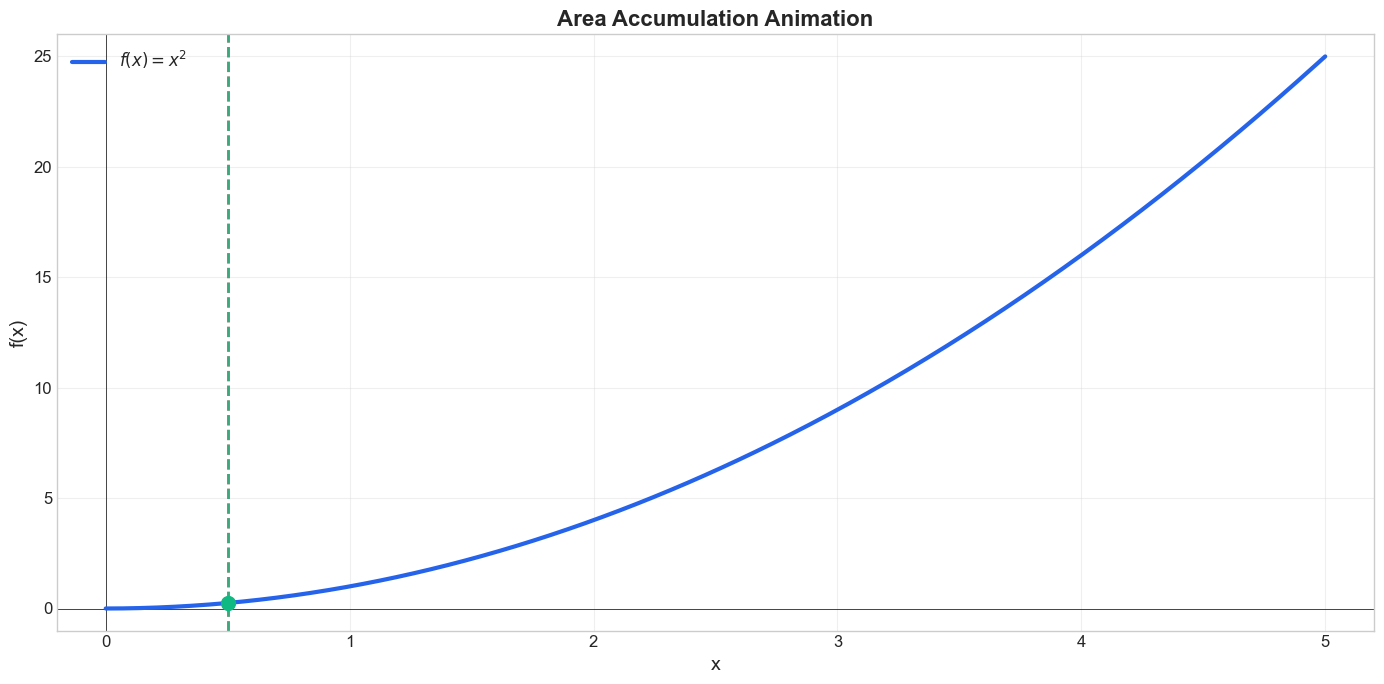

Animation shows area growing from a to b
Notice how the rate of growth increases — this is the power of x^2!


In [5]:
# Section 4: Area Accumulation Animation
fig, ax = plt.subplots(figsize=(14, 7))
x = np.linspace(0, 5, 500); f = lambda x: x**2; y = f(x); a, b = 0.5, 4.0
ax.plot(x, y, color='#2563EB', linewidth=3, label='$f(x) = x^2$', zorder=3)
ax.axhline(y=0, color='black', linewidth=0.5); ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlim(-0.2, 5.2); ax.set_ylim(-1, 26); ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title('Area Accumulation Animation', fontsize=16, fontweight='bold'); ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
ax.axvline(x=a, color='#EF4444', linestyle='--', linewidth=2, alpha=0.8)
fill_collection = []; text_area = ax.text(0.5, 0.85, '', transform=ax.transAxes, fontsize=14, fontweight='bold', color='#7C3AED', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
line_b = ax.axvline(x=a, color='#10B981', linestyle='--', linewidth=2, alpha=0.8); point_b = ax.scatter([a], [a**2], color='#10B981', s=100, zorder=5)
n_frames = 100; b_values = np.linspace(a, b, n_frames)
def init(): text_area.set_text(''); line_b.set_xdata([a, a]); point_b.set_offsets([[a, a**2]]); return text_area, line_b, point_b
def animate(i):
    current_b = b_values[i]; mask = (x >= a) & (x <= current_b); global fill_collection
    for coll in fill_collection: coll.remove()
    fill_collection = []
    coll = ax.fill_between(x, 0, y, where=mask, alpha=0.4, color='#7C3AED', interpolate=True, zorder=2); fill_collection.append(coll)
    area = (current_b**3 - a**3) / 3; text_area.set_text(f'$A = \int_{{{a}}}^{{{current_b:.2f}}} x^2\,dx = {area:.3f}$')
    line_b.set_xdata([current_b, current_b]); point_b.set_offsets([[current_b, current_b**2]]); return text_area, line_b, point_b
anim = animation.FuncAnimation(fig, animate, init_func=init, frames=n_frames, interval=50, blit=False, repeat=True)
plt.tight_layout(); plt.show()
print('Animation shows area growing from a to b')
print('Notice how the rate of growth increases — this is the power of x^2!')

---

# Section 5: Indefinite Integral Explorer

## Concept

The indefinite integral $\int f(x)\,dx = F(x) + C$ represents a **family of curves**, all shifted vertically by the constant $C$.

## Mathematical Definition

$$\int x^2\,dx = \frac{x^3}{3} + C$$

For any value of $C$, the derivative is $x^2$.

## Visual Intuition

All curves in the family have the **same slope** at every $x$ value, so they are parallel curves shifted vertically.

## AI/ML Connection

In optimization, different initial conditions (like $C$) lead to different trajectories, but the 'shape' of learning remains similar.

## Learning Outcome

Understand that the constant of integration $C$ represents initial conditions and family of solutions.

In [6]:
# Section 5: Family of Antiderivatives (C-slider)
x = np.linspace(-3, 3, 500); f = lambda x: x**2
@interact(C=widgets.FloatSlider(value=0, min=-5, max=5, step=0.5, description='Constant C:'))
def indefinite_integral(C):
    F = lambda x: x**3/3 + C; fig, ax = plt.subplots(figsize=(14, 7))
    colors = plt.cm.viridis(np.linspace(0, 1, 11)); C_values = np.linspace(-5, 5, 11)
    for i, c in enumerate(C_values):
        alpha = 1.0 if abs(c - C) < 0.1 else 0.3; lw = 3 if abs(c - C) < 0.1 else 1.5
        ax.plot(x, x**3/3 + c, color=colors[i], linewidth=lw, alpha=alpha, label=f'C = {c:.1f}' if abs(c - C) < 0.1 else '')
    y_selected = F(x); ax.plot(x, y_selected, color='#EF4444', linewidth=4, linestyle='--', label=f'Selected: $F(x) = x^3/3 + {C}$', zorder=5)
    ax.fill_between(x, 0, y_selected, alpha=0.1, color='#EF4444'); ax.set_title(f'Family of Antiderivatives: $F(x) = \int x^2\,dx = \frac{{x^3}}{{3}} + {C}$', fontsize=16, fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('F(x)'); ax.legend(fontsize=11, loc='upper left'); ax.grid(True, alpha=0.3); ax.set_ylim(-8, 13)
    plt.tight_layout(); plt.show()
    print(f'For C = {C}: F\'(x) = d/dx[x^3/3 + {C}] = x^2 = f(x)')
    print('All curves have the same derivative — they are parallel solutions!')

ValueError: 
Family of Antiderivatives: $F(x) = \int x^2\,dx = rac{x^3}{3} + 0.0$
                           ^
ParseException: Expected end of text, found '$'  (at char 27), (line:1, col:28)

<Figure size 1400x700 with 1 Axes>

interactive(children=(FloatSlider(value=0.0, description='Constant C:', max=5.0, min=-5.0, step=0.5), Output()…

---

# Section 6: Fundamental Theorem of Calculus

## Concept

The **Fundamental Theorem of Calculus (FTC)** connects differentiation and integration, showing they are essentially inverse operations.

## Mathematical Definition

**Part 1:** If $f$ is continuous on $[a,b]$, then:

$$F(x) = \int_a^x f(t)\,dt$$

is continuous on $[a,b]$ and differentiable on $(a,b)$, with $F'(x) = f(x)$.

**Part 2:** If $f$ is continuous on $[a,b]$ and $F$ is any antiderivative:

$$\int_a^b f(x)\,dx = F(b) - F(a)$$

## Visual Intuition

The rate of change of accumulated area equals the height of the function.

## AI/ML Connection

FTC enables **automatic differentiation** in deep learning frameworks.

## Learning Outcome

Master the FTC as the bridge between differential and integral calculus.

In [8]:
# Section 6: Fundamental Theorem Visualization
x = np.linspace(0, 5, 500); f = lambda x: x**2; F = lambda x: x**3/3; a, b = 1.0, 3.0
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
y = f(x)
axes[0,0].plot(x, y, color='#2563EB', linewidth=3, label='$f(x) = x^2$'); axes[0,0].set_title('Step 1: Original Function $f(x)$', fontweight='bold')
axes[0,0].set_xlabel('x'); axes[0,0].set_ylabel('f(x)'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)
Y = F(x); axes[0,1].plot(x, Y, color='#06B6D4', linewidth=3, label='$F(x) = x^3/3$'); axes[0,1].scatter([a, b], [F(a), F(b)], color=['#EF4444', '#10B981'], s=100, zorder=5)
axes[0,1].annotate(f'F(a) = {F(a):.2f}', (a, F(a)), xytext=(-30, 20), textcoords='offset points', fontsize=11, color='#EF4444')
axes[0,1].annotate(f'F(b) = {F(b):.2f}', (b, F(b)), xytext=(10, 20), textcoords='offset points', fontsize=11, color='#10B981')
axes[0,1].set_title('Step 2: Antiderivative $F(x)$', fontweight='bold'); axes[0,1].set_xlabel('x'); axes[0,1].set_ylabel('F(x)'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)
axes[1,0].plot(x, y, color='#2563EB', linewidth=3, label='$f(x) = x^2$'); mask = (x >= a) & (x <= b)
axes[1,0].fill_between(x, 0, y, where=mask, alpha=0.4, color='#7C3AED', interpolate=True, label=f'Area = {F(b)-F(a):.3f}')
axes[1,0].axvline(x=a, color='#EF4444', linestyle='--', linewidth=2); axes[1,0].axvline(x=b, color='#10B981', linestyle='--', linewidth=2)
axes[1,0].set_title('Step 3: Area Under Curve', fontweight='bold'); axes[1,0].set_xlabel('x'); axes[1,0].set_ylabel('f(x)'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)
axes[1,1].axis('off'); area_exact = F(b) - F(a); area_numerical = integrate.quad(f, a, b)[0]
text = (
    'FUNDAMENTAL THEOREM OF CALCULUS\n\n'
    f'$\int_a^b f(x)\,dx = F(b) - F(a)$\n\n'
    f'For $f(x) = x^2$ and $F(x) = x^3/3$:\n\n'
    f'$\int_{{{a}}}^{{{b}}} x^2\,dx = \frac{{x^3}}{{3}}\Big|_{{{a}}}^{{{b}}}$\n\n'
    f'$= {area_exact:.4f}$$\n\n'
    f'Numerical verification: {area_numerical:.6f}\n\n'
    'The derivative of the integral gives back f(x):\n'
    '   $d/dx[x^3/3] = x^2$'
)
axes[1,1].text(0.1, 0.5, text, transform=axes[1,1].transAxes, fontsize=14, verticalalignment='center', fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='#F3F4F6', alpha=0.9))
plt.suptitle('Fundamental Theorem of Calculus: Connecting Derivatives and Integrals', fontsize=18, fontweight='bold', y=0.98); plt.tight_layout(); plt.show()
print('FTC verified: Integration and differentiation are inverse operations!')

ValueError: 
$\int_{1.0}^{3.0} x^2\,dx = rac{x^3}{3}\Big|_{1.0}^{3.0}$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

Error in callback <function _draw_all_if_interactive at 0x000001E8B2C85FE0> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
$\int_{1.0}^{3.0} x^2\,dx = rac{x^3}{3}\Big|_{1.0}^{3.0}$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

ValueError: 
$\int_{1.0}^{3.0} x^2\,dx = rac{x^3}{3}\Big|_{1.0}^{3.0}$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

<Figure size 1600x1200 with 4 Axes>

---

# Section 7: Riemann Sum Visualization

## Concept

**Riemann sums** approximate definite integrals by dividing the area into simple shapes (rectangles) and summing their areas.

## Mathematical Definition

$$\sum_{i=1}^{n} f(x_i^*) \Delta x$$

where $\Delta x = \frac{b-a}{n}$ and $x_i^*$ is a sample point in the $i$-th subinterval.

## Visual Intuition

As $n \to \infty$, the approximation converges to the exact integral.

## AI/ML Connection

Riemann sums are the discrete analog of expectation — summing over finite samples approximates the true continuous expectation.

## Learning Outcome

Understand how discrete approximations converge to continuous integrals as resolution increases.

In [ ]:
# Section 7: Interactive Riemann Sum Explorer
x = np.linspace(0, 5, 1000); f = lambda x: x**2
@interact(n=widgets.IntSlider(value=5, min=1, max=50, step=1, description='Rectangles (n):'),
          method=widgets.Dropdown(options=['Left', 'Right', 'Midpoint'], description='Method:'))
def riemann_sum(n, method):
    a, b = 0, 4; dx = (b - a) / n; x_rect = np.linspace(a, b, n+1)
    fig, ax = plt.subplots(figsize=(14, 7)); y = f(x)
    ax.plot(x, y, color='#2563EB', linewidth=3, label='$f(x) = x^2$', zorder=3)
    total_area = 0
    for i in range(n):
        xi = x_rect[i] if method == 'Left' else (x_rect[i+1] if method == 'Right' else (x_rect[i] + x_rect[i+1]) / 2)
        height = f(xi); total_area += height * dx; color = '#7C3AED' if height >= 0 else '#EF4444'
        ax.bar(x_rect[i] + dx/2, height, width=dx, alpha=0.5, color=color, edgecolor='black', linewidth=0.5, zorder=2)
        ax.scatter([xi], [height], color='black', s=30, zorder=4)
    exact = (b**3 - a**3) / 3; error = abs(total_area - exact)
    ax.axhline(y=0, color='black', linewidth=0.5); ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_title(f'{method} Riemann Sum: $n={n}$, Approx = {total_area:.4f}, Error = {error:.4f}', fontsize=16, fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('f(x)'); ax.legend(); ax.grid(True, alpha=0.3); ax.set_xlim(-0.2, 5); ax.set_ylim(-1, 20)
    plt.tight_layout(); plt.show()
    print(f'Approximation: {total_area:.6f}'); print(f'Exact Integral: {exact:.6f}'); print(f'Error: {error:.6f} ({error/exact*100:.2f}%)')
    print('As n -> infinity, error -> 0')

interactive(children=(IntSlider(value=5, description='Rectangles (n):', max=50, min=1), Dropdown(description='…

---

# Section 8: Left Riemann Sum Animation

## Concept

Watch how **Left Riemann Sums** converge to the exact integral as the number of rectangles increases.

## Mathematical Definition

$$L_n = \sum_{i=0}^{n-1} f(x_i) \Delta x$$

where $x_i = a + i\Delta x$ and $\Delta x = \frac{b-a}{n}$.

## Visual Intuition

With left endpoints, rectangles may **underestimate** (increasing function) or **overestimate** (decreasing function).

## AI/ML Connection

Understanding approximation error helps analyze **sampling bias** in ML.

## Learning Outcome

Observe convergence and understand systematic bias in left-endpoint sampling.

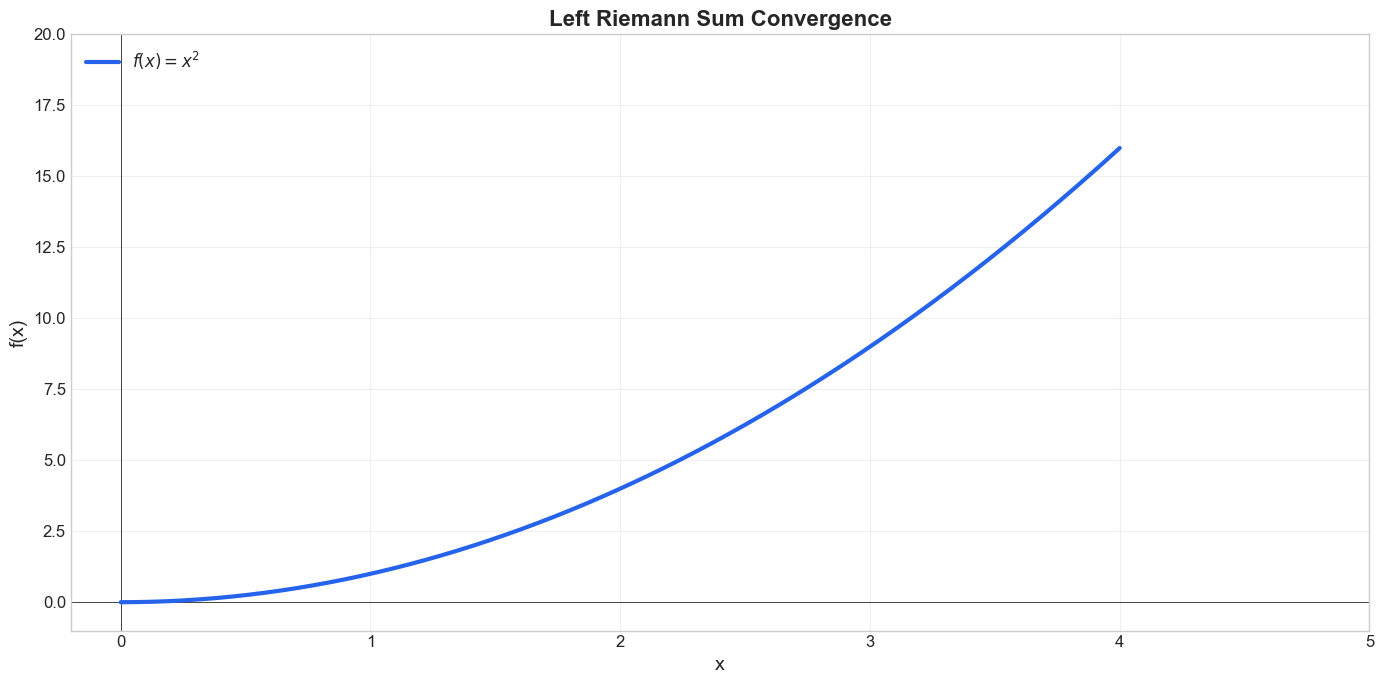

Left Riemann Sum: For increasing functions, left endpoints underestimate
Error decreases as O(1/n) for left/right rules


In [10]:
# Section 8: Left Riemann Sum Convergence Animation
fig, ax = plt.subplots(figsize=(14, 7)); x = np.linspace(0, 4, 500); f = lambda x: x**2; y = f(x)
a, b = 0, 4; exact = (b**3 - a**3) / 3; ax.plot(x, y, color='#2563EB', linewidth=3, label='$f(x) = x^2$', zorder=3)
ax.axhline(y=0, color='black', linewidth=0.5); ax.axvline(x=0, color='black', linewidth=0.5); ax.set_xlim(-0.2, 5); ax.set_ylim(-1, 20)
ax.set_xlabel('x'); ax.set_ylabel('f(x)'); ax.set_title('Left Riemann Sum Convergence', fontsize=16, fontweight='bold'); ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
text_info = ax.text(0.5, 0.85, '', transform=ax.transAxes, fontsize=14, fontweight='bold', color='#7C3AED', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
rects = []; n_values = [1, 2, 3, 4, 5, 8, 10, 15, 20, 30, 50, 100]
def animate_left(i):
    n = n_values[i] if i < len(n_values) else 100; dx = (b - a) / n; global rects
    for rect in rects: rect.remove()
    rects = []; total = 0
    for j in range(n):
        xi = a + j * dx; height = f(xi); total += height * dx
        rect = ax.bar(xi + dx/2, height, width=dx, alpha=0.5, color='#7C3AED', edgecolor='black', linewidth=0.5, zorder=2); rects.extend(rect)
    error = abs(total - exact); text_info.set_text(f'n = {n}\nApprox = {total:.4f}\nExact = {exact:.4f}\nError = {error:.4f}'); return text_info, *rects
anim_left = animation.FuncAnimation(fig, animate_left, frames=len(n_values), interval=800, blit=False, repeat=True)
plt.tight_layout(); plt.show()
print('Left Riemann Sum: For increasing functions, left endpoints underestimate')
print('Error decreases as O(1/n) for left/right rules')

---

# Section 9: Right Riemann Sum Animation

## Concept

Compare **Right Riemann Sums** against Left Riemann Sums. For increasing functions, right endpoints overestimate.

## Mathematical Definition

$$R_n = \sum_{i=1}^{n} f(x_i) \Delta x$$

## Visual Intuition

Left and Right sums bracket the true area. Their average gives a better estimate.

## AI/ML Connection

**Ensemble methods** in ML combine multiple biased estimators to reduce overall bias.

## Learning Outcome

Compare left and right endpoint bias and understand how averaging reduces error.

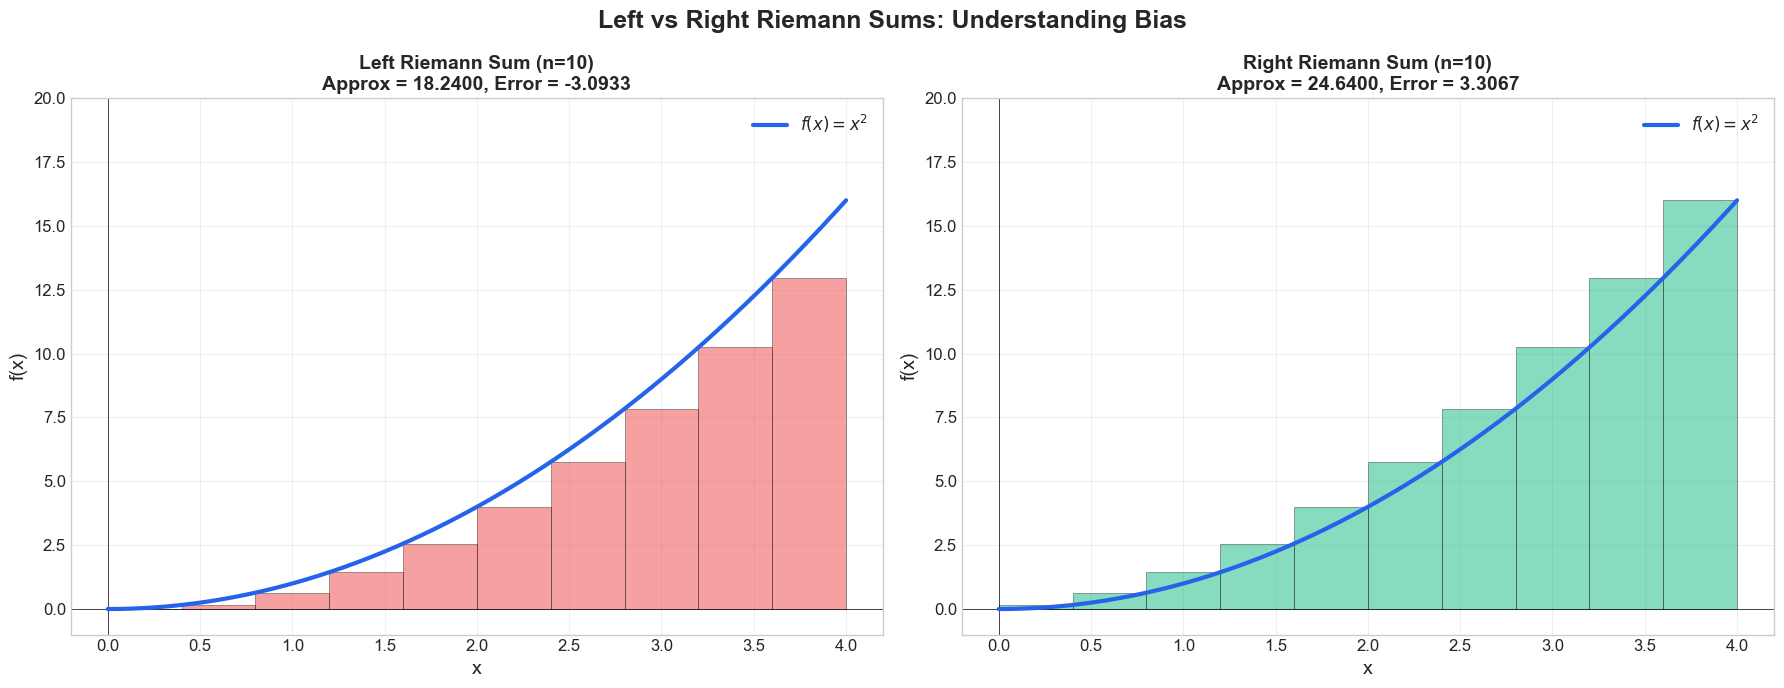

Left Sum:  18.240000 (underestimates)
Right Sum: 24.640000 (overestimates)
Average:   21.440000 (much closer!)
Exact:     21.333333
Averaging left and right reduces error significantly — this is the Trapezoidal Rule!


In [11]:
# Section 9: Right vs Left Riemann Sum Comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 7)); x = np.linspace(0, 4, 500); f = lambda x: x**2; y = f(x); a, b = 0, 4; exact = (b**3 - a**3) / 3; n = 10; dx = (b - a) / n
axes[0].plot(x, y, color='#2563EB', linewidth=3, label='$f(x) = x^2$', zorder=3); left_total = 0
for j in range(n):
    xi = a + j * dx; height = f(xi); left_total += height * dx; axes[0].bar(xi + dx/2, height, width=dx, alpha=0.5, color='#EF4444', edgecolor='black', linewidth=0.5, zorder=2)
axes[0].axhline(y=0, color='black', linewidth=0.5); axes[0].axvline(x=0, color='black', linewidth=0.5)
axes[0].set_title(f'Left Riemann Sum (n={n})\nApprox = {left_total:.4f}, Error = {left_total-exact:.4f}', fontsize=14, fontweight='bold'); axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)'); axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_ylim(-1, 20)
axes[1].plot(x, y, color='#2563EB', linewidth=3, label='$f(x) = x^2$', zorder=3); right_total = 0
for j in range(n):
    xi = a + (j+1) * dx; height = f(xi); right_total += height * dx; axes[1].bar(xi - dx/2, height, width=dx, alpha=0.5, color='#10B981', edgecolor='black', linewidth=0.5, zorder=2)
axes[1].axhline(y=0, color='black', linewidth=0.5); axes[1].axvline(x=0, color='black', linewidth=0.5)
axes[1].set_title(f'Right Riemann Sum (n={n})\nApprox = {right_total:.4f}, Error = {right_total-exact:.4f}', fontsize=14, fontweight='bold'); axes[1].set_xlabel('x'); axes[1].set_ylabel('f(x)'); axes[1].legend(); axes[1].grid(True, alpha=0.3); axes[1].set_ylim(-1, 20)
plt.suptitle('Left vs Right Riemann Sums: Understanding Bias', fontsize=18, fontweight='bold'); plt.tight_layout(); plt.show()
avg = (left_total + right_total) / 2
print(f'Left Sum:  {left_total:.6f} (underestimates)'); print(f'Right Sum: {right_total:.6f} (overestimates)'); print(f'Average:   {avg:.6f} (much closer!)'); print(f'Exact:     {exact:.6f}')
print('Averaging left and right reduces error significantly — this is the Trapezoidal Rule!')

---

# Section 10: Midpoint Rule Visualization

## Concept

The **Midpoint Rule** uses the function value at the center of each subinterval, often providing better accuracy than left or right endpoints.

## Mathematical Definition

$$M_n = \sum_{i=1}^{n} f\left(\frac{x_{i-1} + x_i}{2}\right) \Delta x$$

## Visual Intuition

For smooth functions, errors on the left and right partially cancel out at the midpoint.

## AI/ML Connection

Better sampling strategies (like midpoint) reduce variance in **Monte Carlo estimation**.

## Learning Outcome

Compare midpoint accuracy against left and right rules and understand error cancellation.

In [12]:
# Section 10: Midpoint Rule vs Left/Right Comparison
x = np.linspace(0, 4, 500); f = lambda x: x**2; a, b = 0, 4; exact = (b**3 - a**3) / 3
@interact(n=widgets.IntSlider(value=5, min=1, max=20, step=1, description='n:'))
def midpoint_comparison(n):
    dx = (b - a) / n; fig, axes = plt.subplots(1, 3, figsize=(20, 6)); methods = ['Left', 'Midpoint', 'Right']; colors = ['#EF4444', '#7C3AED', '#10B981']; totals = []
    for idx, method in enumerate(methods):
        ax = axes[idx]; ax.plot(x, f(x), color='#2563EB', linewidth=3, label='$f(x)=x^2$', zorder=3); total = 0
        for j in range(n):
            xi = a + j * dx if method == 'Left' else (a + (j+1) * dx if method == 'Right' else a + (j + 0.5) * dx)
            height = f(xi); total += height * dx; x_bar = a + j * dx + dx/2
            ax.bar(x_bar, height, width=dx, alpha=0.5, color=colors[idx], edgecolor='black', linewidth=0.5, zorder=2); ax.scatter([xi], [height], color='black', s=40, zorder=4)
        totals.append(total); error = abs(total - exact); ax.set_title(f'{method} Rule\nApprox = {total:.5f}\nError = {error:.5f}', fontsize=13, fontweight='bold'); ax.set_xlabel('x'); ax.set_ylabel('f(x)'); ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(-1, 20)
    plt.suptitle(f'Numerical Integration Comparison (n = {n})', fontsize=18, fontweight='bold'); plt.tight_layout(); plt.show()
    print(f"{'Method':<15} {'Approximation':<15} {'Error':<15} {'Error %':<10}"); print('-' * 55)
    for method, total in zip(methods, totals):
        err = abs(total - exact); print(f'{method:<15} {total:<15.6f} {err:<15.6f} {err/exact*100:<10.3f}%')
    print(f'Exact Value: {exact:.6f}'); print('Midpoint Rule typically has half the error of Left/Right Rules!')

interactive(children=(IntSlider(value=5, description='n:', max=20, min=1), Output()), _dom_classes=('widget-in…

---

# Section 11: Trapezoidal Rule Visualization

## Concept

The **Trapezoidal Rule** approximates the area using trapezoids instead of rectangles, fitting linear segments between points.

## Mathematical Definition

$$T_n = \frac{\Delta x}{2}\left[f(x_0) + 2\sum_{i=1}^{n-1}f(x_i) + f(x_n)\right]$$

## Visual Intuition

Trapezoids follow the curve's slope better than flat rectangles, reducing error.

## AI/ML Connection

Linear interpolation (basis of trapezoidal rule) is fundamental to **piecewise linear models** and **linear splines** in ML.

## Learning Outcome

Understand how linear approximations improve upon constant approximations in numerical integration.

In [ ]:
# Section 11: Trapezoidal Rule Visualization
x = np.linspace(0, 4, 500); f = lambda x: x**2; a, b = 0, 4; exact = (b**3 - a**3) / 3
@interact(n=widgets.IntSlider(value=5, min=1, max=30, step=1, description='n (trapezoids):'))
def trapezoidal_rule(n):
    dx = (b - a) / n; x_nodes = np.linspace(a, b, n+1); y_nodes = f(x_nodes); fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(x, f(x), color='#2563EB', linewidth=3, label='$f(x) = x^2$', zorder=3); total = 0
    for i in range(n):
        x_trap = [x_nodes[i], x_nodes[i+1], x_nodes[i+1], x_nodes[i]]; y_trap = [0, 0, y_nodes[i+1], y_nodes[i]]
        ax.fill(x_trap, y_trap, alpha=0.4, color='#06B6D4', edgecolor='black', linewidth=0.5, zorder=2); total += (y_nodes[i] + y_nodes[i+1]) / 2 * dx
    ax.scatter(x_nodes, y_nodes, color='#EF4444', s=50, zorder=4, label='Sample Points'); ax.axhline(y=0, color='black', linewidth=0.5); ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_title(f'Trapezoidal Rule (n={n})\nApprox = {total:.6f}, Error = {abs(total-exact):.6f}', fontsize=16, fontweight='bold'); ax.set_xlabel('x'); ax.set_ylabel('f(x)'); ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(-1, 20)
    plt.tight_layout(); plt.show(); print(f'Trapezoidal Approximation: {total:.8f}'); print(f'Exact Value: {exact:.8f}'); print(f'Error: {abs(total-exact):.8f} ({abs(total-exact)/exact*100:.4f}%)'); print('Trapezoidal Rule = Average of Left and Right Riemann Sums')

interactive(children=(IntSlider(value=5, description='n (trapezoids):', max=30, min=1), Output()), _dom_classe…

---

# Section 12: Simpson's Rule Visualization

## Concept

**Simpson's Rule** approximates the function using **parabolic arcs** (quadratic polynomials) instead of straight lines, achieving much higher accuracy.

## Mathematical Definition

$$S_n = \frac{\Delta x}{3}\left[f(x_0) + 4\sum_{i\text{ odd}}f(x_i) + 2\sum_{i\text{ even}}f(x_i) + f(x_n)\right]$$

## Visual Intuition

Parabolas fit smooth curves better than lines, especially for functions with curvature.

## AI/ML Connection

Higher-order polynomial approximations are the basis of **kernel methods** and **higher-order spline interpolation** in ML.

## Learning Outcome

Appreciate how higher-order approximations dramatically improve numerical integration accuracy.

In [14]:
# Section 12: Simpson's Rule vs Trapezoidal Comparison
x = np.linspace(0, 4, 500); a, b = 0, 4; exact = (b**3 - a**3) / 3; exact_hard = (b**5 - a**5) / 5
@interact(n=widgets.IntSlider(value=4, min=2, max=20, step=2, description='n (must be even):'), func_type=widgets.Dropdown(options=['x^2 (easy)', 'x^4 (hard)'], description='Function:'))
def simpson_rule(n, func_type):
    if n % 2 != 0: n += 1
    if func_type == 'x^2 (easy)': f = lambda x: x**2; exact_val = exact
    else: f = lambda x: x**4; exact_val = exact_hard
    dx = (b - a) / n; x_nodes = np.linspace(a, b, n+1); y_nodes = f(x_nodes); fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    ax = axes[0]; ax.plot(x, f(x), color='#2563EB', linewidth=3, label=f'$f(x) = {func_type[:2]}$', zorder=3); trap_total = 0
    for i in range(n):
        x_trap = [x_nodes[i], x_nodes[i+1], x_nodes[i+1], x_nodes[i]]; y_trap = [0, 0, y_nodes[i+1], y_nodes[i]]
        ax.fill(x_trap, y_trap, alpha=0.3, color='#06B6D4', edgecolor='black', linewidth=0.5, zorder=2); trap_total += (y_nodes[i] + y_nodes[i+1]) / 2 * dx
    ax.scatter(x_nodes, y_nodes, color='#EF4444', s=30, zorder=4); ax.set_title(f'Trapezoidal Rule\nApprox = {trap_total:.6f}, Error = {abs(trap_total-exact_val):.6f}', fontsize=14, fontweight='bold'); ax.set_xlabel('x'); ax.set_ylabel('f(x)'); ax.legend(); ax.grid(True, alpha=0.3)
    ax = axes[1]; ax.plot(x, f(x), color='#2563EB', linewidth=3, label=f'$f(x) = {func_type[:2]}$', zorder=3); simp_total = 0
    for i in range(0, n, 2):
        if i+2 <= n:
            x_s = x_nodes[i:i+3]; y_s = y_nodes[i:i+3]; x_fine = np.linspace(x_s[0], x_s[2], 50)
            L0 = (x_fine - x_s[1])*(x_fine - x_s[2]) / ((x_s[0]-x_s[1])*(x_s[0]-x_s[2])); L1 = (x_fine - x_s[0])*(x_fine - x_s[2]) / ((x_s[1]-x_s[0])*(x_s[1]-x_s[2]))
            L2 = (x_fine - x_s[0])*(x_fine - x_s[1]) / ((x_s[2]-x_s[0])*(x_s[2]-x_s[1])); y_fine = y_s[0]*L0 + y_s[1]*L1 + y_s[2]*L2
            ax.fill_between(x_fine, 0, y_fine, alpha=0.3, color='#7C3AED', zorder=2); ax.plot(x_fine, y_fine, color='#7C3AED', linewidth=2, linestyle='--', zorder=3)
    simp_total = y_nodes[0] + y_nodes[n]
    for i in range(1, n): simp_total += (4 if i % 2 == 1 else 2) * y_nodes[i]
    simp_total *= dx / 3; ax.scatter(x_nodes, y_nodes, color='#10B981', s=50, zorder=4, label='Nodes')
    ax.set_title(f"Simpson's Rule\nApprox = {simp_total:.6f}, Error = {abs(simp_total-exact_val):.6f}", fontsize=14, fontweight='bold'); ax.set_xlabel('x'); ax.set_ylabel('f(x)'); ax.legend(); ax.grid(True, alpha=0.3)
    plt.suptitle(f"Numerical Integration: Trapezoidal vs Simpson's (n = {n})", fontsize=18, fontweight='bold'); plt.tight_layout(); plt.show()
    print(f"{'Method':<20} {'Approximation':<18} {'Error':<18}"); print('-' * 56)
    print(f'{"Trapezoidal":<20} {trap_total:<18.8f} {abs(trap_total-exact_val):<18.8f}'); print(f'{"Simpson":<20} {simp_total:<18.8f} {abs(simp_total-exact_val):<18.8f}'); print(f'{"Exact":<20} {exact_val:<18.8f}')
    print("Simpson's Rule is O(dx^4) accurate vs O(dx^2) for Trapezoidal!")

ValueError: 
f(x) = x^
         ^
ParseSyntaxException: Expected {accent | symbol | function | operatorname | group | frac | dfrac | binom | genfrac | overset | underset | sqrt | overline | text | boldsymbol | substack}, found end of text  (at char 9), (line:1, col:10)

<Figure size 1800x700 with 2 Axes>

interactive(children=(IntSlider(value=4, description='n (must be even):', max=20, min=2, step=2), Dropdown(des…

ValueError: 
f(x) = x^
         ^
ParseSyntaxException: Expected {accent | symbol | function | operatorname | group | frac | dfrac | binom | genfrac | overset | underset | sqrt | overline | text | boldsymbol | substack}, found end of text  (at char 9), (line:1, col:10)

ValueError: 
f(x) = x^
         ^
ParseSyntaxException: Expected {accent | symbol | function | operatorname | group | frac | dfrac | binom | genfrac | overset | underset | sqrt | overline | text | boldsymbol | substack}, found end of text  (at char 9), (line:1, col:10)

<Figure size 1800x700 with 2 Axes>

---

# Section 13: Numerical Integration Dashboard

## Concept

A unified dashboard comparing all numerical integration methods on any function you choose.

## Mathematical Definition

Compare: Left Riemann, Right Riemann, Midpoint, Trapezoidal, Simpson's.

## AI/ML Connection

Choosing the right approximation method is like choosing the right **model architecture** — trade-offs between accuracy and computational cost.

## Learning Outcome

Evaluate and compare all numerical integration methods in one interactive environment.

In [15]:
# Section 13: Complete Numerical Integration Dashboard
@interact(func_str=widgets.Dropdown(options=['x**2', 'x**3', 'sin(x)', 'exp(x)', '1/(1+x**2)'], value='x**2', description='Function:'),
          a=widgets.FloatSlider(value=0, min=-2, max=2, step=0.1, description='a:'),
          b=widgets.FloatSlider(value=4, min=2, max=6, step=0.1, description='b:'),
          n=widgets.IntSlider(value=10, min=2, max=100, step=2, description='n:'))
def integration_dashboard(func_str, a, b, n):
    if a >= b: print('Need a < b'); return
    x_sym = symbols('x')
    if func_str == 'x**2': f = lambda x: x**2; f_sym = x_sym**2
    elif func_str == 'x**3': f = lambda x: x**3; f_sym = x_sym**3
    elif func_str == 'sin(x)': f = lambda x: np.sin(x); f_sym = sp.sin(x_sym)
    elif func_str == 'exp(x)': f = lambda x: np.exp(x); f_sym = sp.exp(x_sym)
    else: f = lambda x: 1/(1+x**2); f_sym = 1/(1+x_sym**2)
    exact = float(sym_integrate(f_sym, (x_sym, a, b))); dx = (b - a) / n; x_nodes = np.linspace(a, b, n+1); y_nodes = f(x_nodes)
    left = sum(f(a + i*dx) * dx for i in range(n)); right = sum(f(a + (i+1)*dx) * dx for i in range(n)); mid = sum(f(a + (i+0.5)*dx) * dx for i in range(n)); trap = (y_nodes[0] + 2*sum(y_nodes[1:n]) + y_nodes[n]) * dx / 2
    if n % 2 == 0: simp = y_nodes[0] + y_nodes[n]; [simp := simp + (4 if i % 2 == 1 else 2) * y_nodes[i] for i in range(1, n)]; simp *= dx / 3
    else: simp = None
    fig, ax = plt.subplots(figsize=(14, 7)); x_fine = np.linspace(a, b, 500)
    ax.plot(x_fine, f(x_fine), color='#2563EB', linewidth=3, label=f'$f(x) = {func_str}$', zorder=3); ax.fill_between(x_fine, 0, f(x_fine), alpha=0.2, color='#7C3AED', label=f'Exact Area = {exact:.6f}'); ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_title(f'Numerical Integration Dashboard: $\int_{{{a}}}^{{{b}}} {func_str}\,dx$', fontsize=16, fontweight='bold'); ax.set_xlabel('x'); ax.set_ylabel('f(x)'); ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show(); print(f"{'Method':<15} {'Approximation':<18} {'Error':<18} {'Rel. Error %':<12}"); print('=' * 65)
    results = [('Left', left), ('Right', right), ('Midpoint', mid), ('Trapezoidal', trap)]; [results.append(('Simpson', simp)) if simp is not None else None]
    for name, val in results:
        err = abs(val - exact); rel = err / abs(exact) * 100 if exact != 0 else float('inf'); print(f'{name:<15} {val:<18.8f} {err:<18.8f} {rel:<12.4f}%')
    print(f'{"Exact":<15} {exact:<18.8f}'); print(f"Best method: {'Simpson' if simp and abs(simp-exact) < abs(trap-exact) else 'Trapezoidal/Midpoint'}")

interactive(children=(Dropdown(description='Function:', options=('x**2', 'x**3', 'sin(x)', 'exp(x)', '1/(1+x**…

---

# Section 14: Improper Integral Visualization

## Concept

**Improper integrals** have infinite limits or unbounded integrands. They converge if the limit exists and is finite.

## Mathematical Definition

$$\int_1^{\infty} \frac{1}{x^2}\,dx = \lim_{b \to \infty} \int_1^{b} \frac{1}{x^2}\,dx = \lim_{b \to \infty}\left[-\frac{1}{x}\right]_1^b = 1$$

## Visual Intuition

Even though the region extends infinitely, the area can be finite if the function decays fast enough.

## AI/ML Connection

Improper integrals appear in **normalization constants** of probability distributions and **expected values** of heavy-tailed distributions.

## Learning Outcome

Visualize convergence of infinite integrals and understand the balance between infinite extent and decay rate.

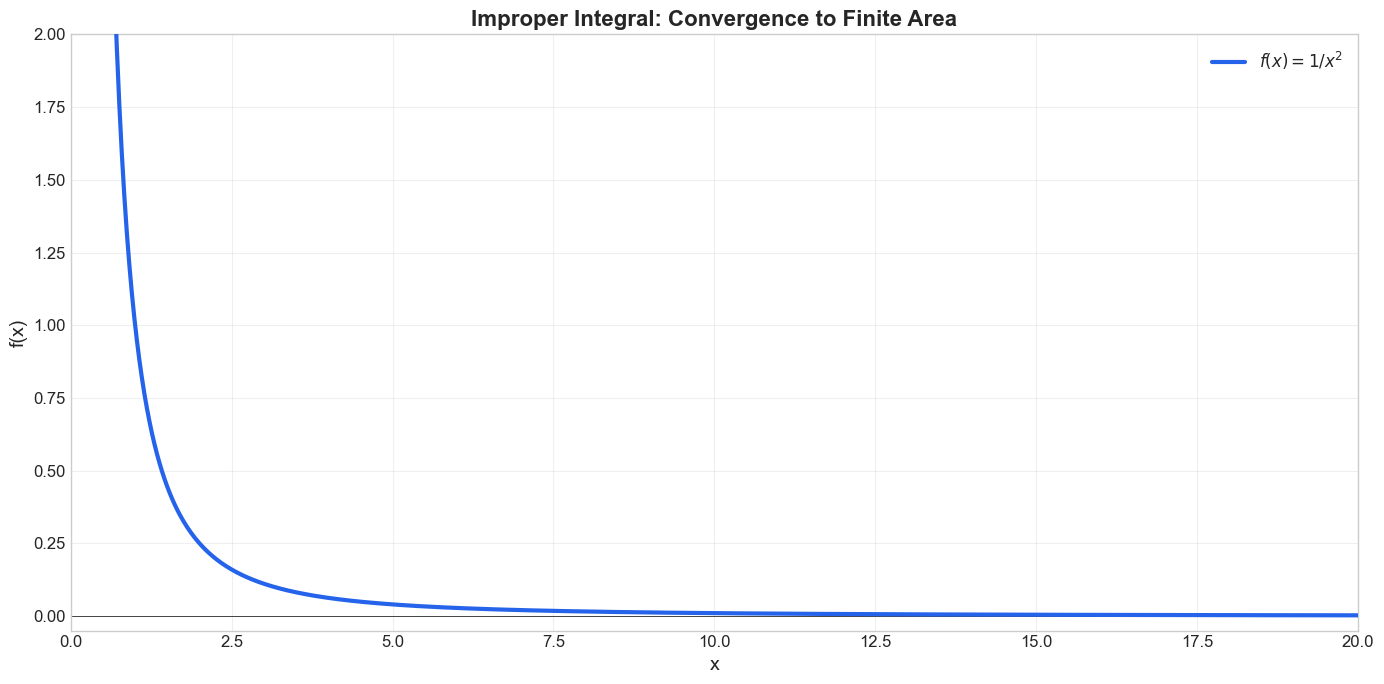

Animation shows: Even with infinite upper bound, area converges to 1!
Integral from 1 to infinity of 1/x^2 dx = 1 (converges)
Integral from 1 to infinity of 1/x dx = infinity (diverges)
In ML: This is why Gaussian tails are well-behaved but heavy-tailed distributions need care


In [16]:
# Section 14: Improper Integral Animation
fig, ax = plt.subplots(figsize=(14, 7)); x = np.linspace(0.5, 20, 1000); f = lambda x: 1/x**2; y = f(x)
ax.plot(x, y, color='#2563EB', linewidth=3, label='$f(x) = 1/x^2$', zorder=3); ax.axhline(y=0, color='black', linewidth=0.5); ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlim(0, 20); ax.set_ylim(-0.05, 2); ax.set_xlabel('x'); ax.set_ylabel('f(x)'); ax.set_title('Improper Integral: Convergence to Finite Area', fontsize=16, fontweight='bold'); ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)
text_info = ax.text(0.5, 0.85, '', transform=ax.transAxes, fontsize=14, fontweight='bold', color='#7C3AED', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)); fill_collection = []; b_values = np.concatenate([np.linspace(1, 5, 30), np.linspace(5, 15, 30), np.linspace(15, 50, 40)])
def animate_improper(i):
    current_b = b_values[i]; mask = (x >= 1) & (x <= current_b); global fill_collection
    for coll in fill_collection: coll.remove()
    fill_collection = []; coll = ax.fill_between(x, 0, y, where=mask, alpha=0.4, color='#7C3AED', interpolate=True, zorder=2); fill_collection.append(coll)
    area = 1 - 1/current_b; text_info.set_text(f'$\int_1^{{{current_b:.1f}}} \frac{{1}}{{x^2}}\,dx = {area:.4f}$\nLimit = 1.0000'); return text_info, *fill_collection
anim_improper = animation.FuncAnimation(fig, animate_improper, frames=len(b_values), interval=80, blit=False, repeat=True)
plt.tight_layout(); plt.show(); print('Animation shows: Even with infinite upper bound, area converges to 1!'); print('Integral from 1 to infinity of 1/x^2 dx = 1 (converges)'); print('Integral from 1 to infinity of 1/x dx = infinity (diverges)'); print('In ML: This is why Gaussian tails are well-behaved but heavy-tailed distributions need care')

---

# Section 15: Double Integral Visualization

## Concept

**Double integrals** extend integration to two dimensions, computing volumes under surfaces over regions in the plane.

## Mathematical Definition

$$\iint_R f(x,y)\,dA$$

For $R = [a,b] \times [c,d]$:

$$\iint_R f(x,y)\,dA = \int_a^b\int_c^d f(x,y)\,dy\,dx$$

## Visual Intuition

The volume is the sum of infinitesimal columns $f(x,y)\,dx\,dy$ over the region $R$.

## AI/ML Connection

Double integrals compute **joint probabilities** $P(X,Y)$ over 2D distributions and **expected values** of bivariate random variables.

## Learning Outcome

Visualize 3D volumes and understand how double integrals accumulate over 2D regions.

In [17]:
# Section 15: Double Integral 3D Visualization
x = np.linspace(-2, 2, 100); y = np.linspace(-2, 2, 100); X, Y = np.meshgrid(x, y); Z = X**2 + Y**2
fig = plt.figure(figsize=(16, 12)); ax1 = fig.add_subplot(2, 2, 1, projection='3d'); surf = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, edgecolor='none')
ax1.set_title('Surface: $f(x,y) = x^2 + y^2$', fontweight='bold', fontsize=14); ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z'); fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)
ax2 = fig.add_subplot(2, 2, 2, projection='3d'); ax2.plot_surface(X, Y, Z, cmap='viridis', alpha=0.3, edgecolor='none'); x_r = np.linspace(-1, 1, 50); y_r = np.linspace(-1, 1, 50); X_r, Y_r = np.meshgrid(x_r, y_r); Z_r = X_r**2 + Y_r**2
ax2.plot_surface(X_r, Y_r, Z_r, cmap='plasma', alpha=0.9, edgecolor='none'); ax2.set_title('Integration Region $R = [-1,1] \times [-1,1]$', fontweight='bold', fontsize=14); ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')
ax3 = fig.add_subplot(2, 2, 3); contour = ax3.contourf(X, Y, Z, levels=20, cmap='viridis'); ax3.contour(X, Y, Z, levels=20, colors='black', linewidths=0.5, alpha=0.5); rect = plt.Rectangle((-1, -1), 2, 2, fill=False, edgecolor='red', linewidth=3, linestyle='--'); ax3.add_patch(rect)
ax3.set_title('Contour Plot with Region R', fontweight='bold', fontsize=14); ax3.set_xlabel('x'); ax3.set_ylabel('y'); fig.colorbar(contour, ax=ax3)
ax4 = fig.add_subplot(2, 2, 4); ax4.axis('off'); x_sym, y_sym = symbols('x y', real=True); f_sym = x_sym**2 + y_sym**2; exact_double = float(sym_integrate(sym_integrate(f_sym, (y_sym, -1, 1)), (x_sym, -1, 1)))
text = ('DOUBLE INTEGRAL\n\n$$\iint_R (x^2 + y^2)\,dA$$\n\nOver $R = [-1,1] \times [-1,1]$:\n\n$$= \int_{-1}^{1} \int_{-1}^{1} (x^2 + y^2)\,dy\,dx$$\n\n$$= \int_{-1}^{1} \left[x^2y + \frac{y^3}{3}\right]_{-1}^{1}\,dx$$\n\n$$= \int_{-1}^{1} \left(2x^2 + \frac{2}{3}\right)\,dx$$\n\n$$= \left[\frac{2x^3}{3} + \frac{2x}{3}\right]_{-1}^{1}$$\n\n' + f'$$= {exact_double:.4f}$$\n\n' + f'Numerical: {integrate.dblquad(lambda y, x: x**2 + y**2, -1, 1, -1, 1)[0]:.6f}')
ax4.text(0.1, 0.5, text, transform=ax4.transAxes, fontsize=13, verticalalignment='center', fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='#F3F4F6', alpha=0.9))
plt.suptitle('Double Integrals: From Area to Volume', fontsize=18, fontweight='bold'); plt.tight_layout(); plt.show(); print(f'Exact Double Integral: {exact_double:.6f}'); print('Double integrals compute volume under a surface over a 2D region')

ValueError: 
$$\iint_R (x^2 + y^2)\,dA$$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

Error in callback <function _draw_all_if_interactive at 0x000001E8B2C85FE0> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
$$\iint_R (x^2 + y^2)\,dA$$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

ValueError: 
$$\iint_R (x^2 + y^2)\,dA$$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

<Figure size 1600x1200 with 6 Axes>

---

# Section 16: Double Integral Animation

## Concept

Animate the **volume accumulation** as the integration region expands, showing how area becomes volume.

## Mathematical Definition

$$V(t) = \int_{-t}^{t}\int_{-t}^{t} (x^2 + y^2)\,dy\,dx$$

As $t$ grows from 0, the volume accumulates over the expanding square region.

## Visual Intuition

Volume grows as the base region expands, with the rate depending on the height function.

## AI/ML Connection

This represents how **joint probability mass** accumulates as we expand the region of interest in 2D feature space.

## Learning Outcome

Watch 2D integration as a dynamic accumulation process in 3D space.

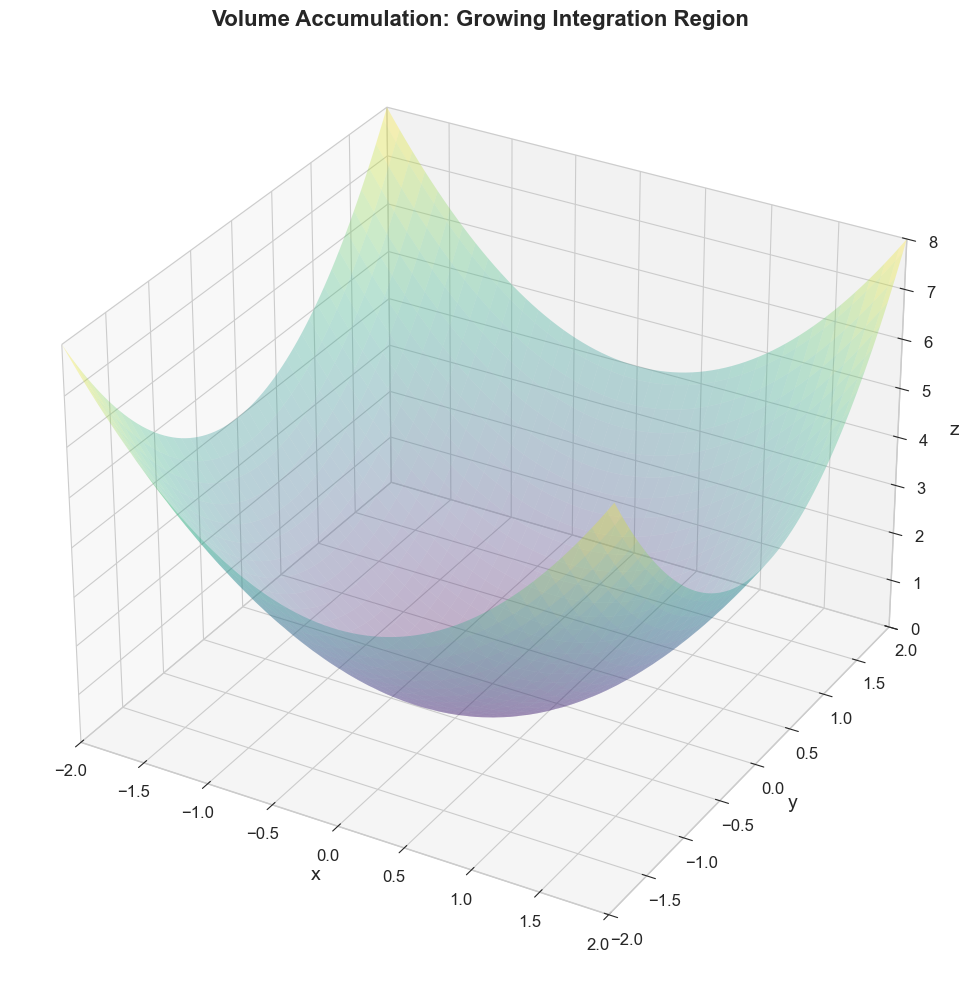

Volume grows as t^3 — the power of 3D accumulation!
For f(x,y) = x^2 + y^2 over [-t,t]x[-t,t]: Volume = 8t^3/3


In [18]:
# Section 16: Volume Accumulation Animation
fig = plt.figure(figsize=(14, 10)); ax = fig.add_subplot(111, projection='3d'); x = np.linspace(-2, 2, 80); y = np.linspace(-2, 2, 80); X, Y = np.meshgrid(x, y); Z = X**2 + Y**2
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.3, edgecolor='none', zorder=1); ax.set_xlim(-2, 2); ax.set_ylim(-2, 2); ax.set_zlim(0, 8); ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Volume Accumulation: Growing Integration Region', fontsize=16, fontweight='bold'); text_info = fig.text(0.5, 0.02, '', ha='center', fontsize=14, fontweight='bold', color='#7C3AED'); n_frames = 50; t_values = np.linspace(0.1, 2, n_frames); surf_dynamic = [None]
def animate_double(i):
    t = t_values[i]
    if surf_dynamic[0] is not None: surf_dynamic[0].remove()
    x_r = np.linspace(-t, t, 40); y_r = np.linspace(-t, t, 40); X_r, Y_r = np.meshgrid(x_r, y_r); Z_r = X_r**2 + Y_r**2
    surf_dynamic[0] = ax.plot_surface(X_r, Y_r, Z_r, cmap='plasma', alpha=0.9, edgecolor='none', zorder=2); exact_t = 8*t**3/3
    text_info.set_text(f'Region: [-{t:.2f}, {t:.2f}] x [-{t:.2f}, {t:.2f}] | Volume = {exact_t:.4f}'); return surf_dynamic[0], text_info
anim_double = animation.FuncAnimation(fig, animate_double, frames=n_frames, interval=100, blit=False, repeat=True)
plt.tight_layout(); plt.show(); print('Volume grows as t^3 — the power of 3D accumulation!'); print('For f(x,y) = x^2 + y^2 over [-t,t]x[-t,t]: Volume = 8t^3/3')

---

# Section 17: Triple Integral Concept Explorer

## Concept

**Triple integrals** extend integration to three dimensions, computing hypervolumes or accumulated quantities in 3D space.

## Mathematical Definition

$$\iiint_V f(x,y,z)\,dV$$

For a rectangular box $V = [a,b] \times [c,d] \times [e,f]$:

$$\iiint_V f(x,y,z)\,dV = \int_a^b\int_c^d\int_e^f f(x,y,z)\,dz\,dy\,dx$$

## Visual Intuition

Sum infinitesimal cubes $f(x,y,z)\,dx\,dy\,dz$ throughout the volume $V$.

## AI/ML Connection

Triple integrals appear in **3D probability densities**, **spatial statistics**, and **physics-informed neural networks** solving PDEs in 3D.

## Learning Outcome

Conceptualize integration in 3D space and understand the nested accumulation process.

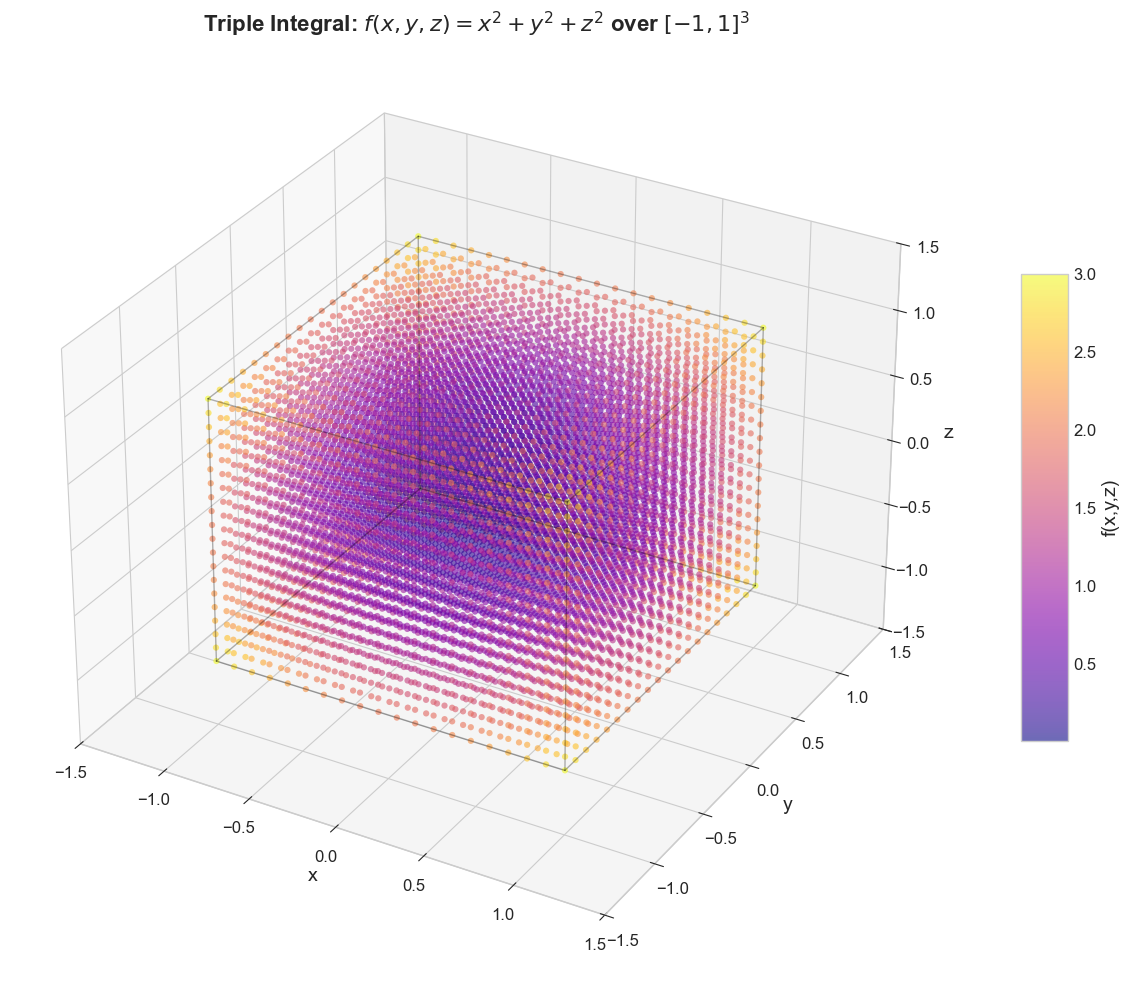

Exact Triple Integral over [-1,1]^3: 8.000000
Integral of (x^2 + y^2 + z^2) dV = 8.0000
Triple integrals accumulate over 3D volumes — essential for spatial AI and physics simulations


In [19]:
# Section 17: Triple Integral 3D Volumetric Visualization
from mpl_toolkits.mplot3d import Axes3D; import matplotlib.patches as mpatches; from itertools import combinations, product
fig = plt.figure(figsize=(16, 10)); ax = fig.add_subplot(111, projection='3d'); n_points = 20; x_pts = np.linspace(-1, 1, n_points); y_pts = np.linspace(-1, 1, n_points); z_pts = np.linspace(-1, 1, n_points)
X_pts, Y_pts, Z_pts = np.meshgrid(x_pts, y_pts, z_pts); F_vals = X_pts**2 + Y_pts**2 + Z_pts**2; x_flat = X_pts.flatten(); y_flat = Y_pts.flatten(); z_flat = Z_pts.flatten(); f_flat = F_vals.flatten()
colors = plt.cm.plasma((f_flat - f_flat.min()) / (f_flat.max() - f_flat.min())); scatter = ax.scatter(x_flat, y_flat, z_flat, c=f_flat, cmap='plasma', s=20, alpha=0.6, edgecolors='none')
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5); ax.set_zlim(-1.5, 1.5); ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z'); ax.set_title('Triple Integral: $f(x,y,z) = x^2 + y^2 + z^2$ over $[-1,1]^3$', fontsize=16, fontweight='bold')
for s, e in combinations(np.array(list(product([-1,1], [-1,1], [-1,1]))), 2):
    if np.sum(np.abs(s-e)) == 2: ax.plot3D(*zip(s, e), color='black', alpha=0.3, linewidth=1)
cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10, label='f(x,y,z)'); plt.tight_layout(); plt.show(); x_sym, y_sym, z_sym = symbols('x y z', real=True); f_sym = x_sym**2 + y_sym**2 + z_sym**2
exact_triple = float(sym_integrate(sym_integrate(sym_integrate(f_sym, (z_sym, -1, 1)), (y_sym, -1, 1)), (x_sym, -1, 1)))
print(f'Exact Triple Integral over [-1,1]^3: {exact_triple:.6f}'); print(f'Integral of (x^2 + y^2 + z^2) dV = {exact_triple:.4f}'); print('Triple integrals accumulate over 3D volumes — essential for spatial AI and physics simulations')

---

# Section 18: Probability Density Function Visualization

## Concept

A **Probability Density Function (PDF)** describes the likelihood of a continuous random variable. The total probability (integral over all space) equals 1.

## Mathematical Definition

**Gaussian (Normal) Distribution:**

$$p(x) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

where $\mu$ is the mean and $\sigma$ is the standard deviation.

## Visual Intuition

The bell curve: higher near the mean, symmetric, with spread controlled by $\sigma$.

## AI/ML Connection

Gaussian distributions are the foundation of **Gaussian processes**, **variational inference**, **diffusion models**, and **noise modeling** in ML.

## Learning Outcome

Interactively explore how mean and variance shape the Gaussian distribution.

In [20]:
# Section 18: Interactive Gaussian Distribution Explorer
x = np.linspace(-10, 10, 1000)
@interact(mu=widgets.FloatSlider(value=0, min=-5, max=5, step=0.1, description='Mean (mu):'), sigma=widgets.FloatSlider(value=1, min=0.3, max=3, step=0.1, description='Std Dev (sigma):'))
def gaussian_pdf(mu, sigma):
    y = norm.pdf(x, mu, sigma); fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(x, y, color='#2563EB', linewidth=3, label=f'$p(x) = \mathcal{{N}}({mu}, {sigma}^2)$', zorder=3); ax.fill_between(x, 0, y, alpha=0.3, color='#7C3AED', zorder=2)
    ax.axvline(x=mu, color='#EF4444', linestyle='--', linewidth=2, alpha=0.8, label=f'Mean mu = {mu}', zorder=3); ax.axvline(x=mu-sigma, color='#10B981', linestyle=':', linewidth=1.5, alpha=0.6); ax.axvline(x=mu+sigma, color='#10B981', linestyle=':', linewidth=1.5, alpha=0.6)
    ax.fill_betweenx([0, y.max()], mu-sigma, mu+sigma, alpha=0.1, color='#10B981', label=f'+/-1 sigma = [{mu-sigma:.1f}, {mu+sigma:.1f}]'); peak_y = norm.pdf(mu, mu, sigma); ax.scatter([mu], [peak_y], color='#EF4444', s=100, zorder=5)
    ax.annotate(f'Peak: {peak_y:.3f}', (mu, peak_y), xytext=(10, 20), textcoords='offset points', fontsize=11, fontweight='bold'); ax.axhline(y=0, color='black', linewidth=0.5); ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_title(f'Gaussian PDF: $\mu = {mu}$, $\sigma = {sigma}$', fontsize=16, fontweight='bold'); ax.set_xlabel('x'); ax.set_ylabel('p(x)'); ax.legend(fontsize=11, loc='upper right'); ax.grid(True, alpha=0.3); ax.set_xlim(-10, 10); ax.set_ylim(-0.02, 0.5)
    plt.tight_layout(); plt.show(); total_prob = integrate.quad(lambda x: norm.pdf(x, mu, sigma), -np.inf, np.inf)[0]; print(f'Total Probability (should be 1): {total_prob:.6f}'); print(f'Mean: {mu}, Std Dev: {sigma}'); print(f'Variance: {sigma**2}'); print(f'68% of probability lies within [mu-sigma, mu+sigma] = [{mu-sigma:.2f}, {mu+sigma:.2f}]')

interactive(children=(FloatSlider(value=0.0, description='Mean (mu):', max=5.0, min=-5.0), FloatSlider(value=1…

---

# Section 19: Probability Area Animation

## Concept

The probability that $X$ falls in interval $[a,b]$ is the **area under the PDF**:

$$P(a < X < b) = \int_a^b p(x)\,dx$$

## Mathematical Definition

For Gaussian distribution:

$$P(a < X < b) = \int_a^b \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}\,dx$$

## Visual Intuition

Shaded area under the curve = probability of the event.

## AI/ML Connection

Computing probability intervals is essential for **confidence intervals**, **hypothesis testing**, and **Bayesian credible intervals**.

## Learning Outcome

Interactively select intervals and see probability accumulation in real-time.

In [21]:
# Section 19: Interactive Probability Area Selection
x = np.linspace(-8, 8, 1000); mu, sigma = 0, 1; y = norm.pdf(x, mu, sigma)
@interact(a=widgets.FloatSlider(value=-1, min=-4, max=3, step=0.1, description='a:'), b=widgets.FloatSlider(value=1, min=-3, max=4, step=0.1, description='b:'))
def probability_area(a, b):
    if a >= b: a, b = b, a
    fig, ax = plt.subplots(figsize=(14, 7)); ax.plot(x, y, color='#2563EB', linewidth=3, label='$p(x) = \mathcal{N}(0,1)$', zorder=3)
    mask = (x >= a) & (x <= b); prob = norm.cdf(b, mu, sigma) - norm.cdf(a, mu, sigma); ax.fill_between(x, 0, y, where=mask, alpha=0.5, color='#7C3AED', interpolate=True, label=f'$P({a} < X < {b})$', zorder=2)
    ax.axvline(x=a, color='#EF4444', linestyle='--', linewidth=2, alpha=0.8, zorder=3); ax.axvline(x=b, color='#10B981', linestyle='--', linewidth=2, alpha=0.8, zorder=3)
    ax.text(0.5, 0.85, f'$P({a} < X < {b}) = {prob:.4f}$', transform=ax.transAxes, fontsize=16, fontweight='bold', color='#7C3AED', ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='#7C3AED'))
    ax.axhline(y=0, color='black', linewidth=0.5); ax.axvline(x=0, color='black', linewidth=0.5); ax.set_title('Probability as Area Under PDF', fontsize=16, fontweight='bold'); ax.set_xlabel('x'); ax.set_ylabel('p(x)'); ax.legend(fontsize=12); ax.grid(True, alpha=0.3); ax.set_xlim(-8, 8); ax.set_ylim(-0.02, 0.45)
    plt.tight_layout(); plt.show(); print(f'P({a} < X < {b}) = {prob:.6f}'); print(f'This represents {prob*100:.2f}% of the total probability mass'); print('In ML: This is how we compute confidence intervals and decision boundaries')

interactive(children=(FloatSlider(value=-1.0, description='a:', max=3.0, min=-4.0), FloatSlider(value=1.0, des…

---

# Section 20: Expected Value Visualization

## Concept

The **Expected Value** $E[X]$ is the probability-weighted average of all possible values. It represents the 'center of mass' of the distribution.

## Mathematical Definition

$$E[X] = \int_{-\infty}^{\infty} x \cdot p(x)\,dx$$

For Gaussian: $E[X] = \mu$

## Visual Intuition

The balance point of the distribution — if you cut out the PDF curve, this is where it would balance on a fulcrum.

## AI/ML Connection

Expected values drive **loss minimization**, **policy evaluation** in RL, and **feature importance** in probabilistic models.

## Learning Outcome

Visualize the expected value as the weighted average and center of mass.

In [22]:
# Section 20: Expected Value Visualization
x = np.linspace(-6, 6, 1000); mu, sigma = 2, 1.5; y = norm.pdf(x, mu, sigma); fig, axes = plt.subplots(1, 2, figsize=(18, 7))
ax = axes[0]; ax.plot(x, y, color='#2563EB', linewidth=3, label=f'$p(x) = \mathcal{{N}}({mu}, {sigma}^2)$', zorder=3); ax.fill_between(x, 0, y, alpha=0.3, color='#7C3AED', zorder=2)
ax.axvline(x=mu, color='#EF4444', linestyle='--', linewidth=3, alpha=0.8, label=f'$E[X] = \mu = {mu}$', zorder=4); ax.scatter([mu], [norm.pdf(mu, mu, sigma)], color='#EF4444', s=150, zorder=5, marker='D')
for xi in np.linspace(-4, 6, 15):
    yi = norm.pdf(xi, mu, sigma)
    if yi > 0.01:
        ax.plot([xi, xi], [0, yi], color='#10B981', alpha=0.3, linewidth=1); ax.scatter([xi], [yi], color='#10B981', s=20, alpha=0.5, zorder=3)
ax.axhline(y=0, color='black', linewidth=0.5); ax.axvline(x=0, color='black', linewidth=0.5); ax.set_title('Expected Value: Center of Mass', fontsize=16, fontweight='bold'); ax.set_xlabel('x'); ax.set_ylabel('p(x)'); ax.legend(fontsize=12); ax.grid(True, alpha=0.3); ax.set_ylim(-0.02, 0.35)
ax = axes[1]; ax.axis('off'); E_X = integrate.quad(lambda x: x * norm.pdf(x, mu, sigma), -np.inf, np.inf)[0]; E_X2 = integrate.quad(lambda x: x**2 * norm.pdf(x, mu, sigma), -np.inf, np.inf)[0]; Var = E_X2 - E_X**2
text = ('EXPECTED VALUE\n\n$$E[X] = \int_{-\infty}^{\infty} x \cdot p(x)\,dx$$\n\n' + f'For $p(x) = \mathcal{{N}}({mu}, {sigma}^2)$:\n\n' + f'$$E[X] = \int_{{-\infty}}^{{\infty}} x \cdot \frac{{1}}{{\sqrt{{2\pi{sigma}^2}}}} e^{{-\frac{{(x-{mu})^2}}{{2 \cdot {sigma}^2}}}}\,dx$$\n\n' + f'$$= {E_X:.4f}$$\n\n' + 'Variance:\n' + f'$$Var(X) = E[X^2] - (E[X])^2 = {Var:.4f}$$\n\n' + f'$$\sigma = \sqrt{{Var(X)}} = {np.sqrt(Var):.4f}$$\n\n' + 'Key Properties:\n' + '  E[X] = mu for Gaussian\n' + '  E[aX + b] = a*E[X] + b\n' + '  E[X + Y] = E[X] + E[Y]')
ax.text(0.1, 0.5, text, transform=ax.transAxes, fontsize=13, verticalalignment='center', fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='#F3F4F6', alpha=0.9))
plt.suptitle('Expected Value: The Heart of Probability Distributions', fontsize=18, fontweight='bold'); plt.tight_layout(); plt.show(); print(f'Numerical E[X] = {E_X:.6f} (should equal mu = {mu})'); print(f'Numerical Var(X) = {Var:.6f} (should equal sigma^2 = {sigma**2})')

ValueError: 
$$E[X] = \int_{-\infty}^{\infty} x \cdot p(x)\,dx$$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

Error in callback <function _draw_all_if_interactive at 0x000001E8B2C85FE0> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
$$E[X] = \int_{-\infty}^{\infty} x \cdot p(x)\,dx$$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

ValueError: 
$$E[X] = \int_{-\infty}^{\infty} x \cdot p(x)\,dx$$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

<Figure size 1800x700 with 2 Axes>

---

# Section 21: Gaussian Distribution Playground

## Concept

A complete interactive playground for exploring Gaussian distributions, probability intervals, and expected values.

## Mathematical Definition

$$X \sim \mathcal{N}(\mu, \sigma^2)$$

$$P(a < X < b) = \Phi\left(\frac{b-\mu}{\sigma}\right) - \Phi\left(\frac{a-\mu}{\sigma}\right)$$

where $\Phi$ is the standard normal CDF.

## Visual Intuition

Interactive controls reveal how parameters shape probability and how intervals capture different confidence levels.

## AI/ML Connection

Gaussian parameter tuning is central to **Gaussian Mixture Models**, **Kalman Filters**, and **probabilistic PCA**.

## Learning Outcome

Master Gaussian distributions through complete interactive control of all parameters.

In [23]:
# Section 21: Complete Gaussian Playground
x = np.linspace(-10, 10, 1000)
@interact(mu=widgets.FloatSlider(value=0, min=-5, max=5, step=0.1, description='Mean mu:'), sigma=widgets.FloatSlider(value=1, min=0.2, max=3, step=0.1, description='Std sigma:'), a=widgets.FloatSlider(value=-1, min=-5, max=0, step=0.1, description='Lower a:'), b=widgets.FloatSlider(value=1, min=0, max=5, step=0.1, description='Upper b:'))
def gaussian_playground(mu, sigma, a, b):
    y = norm.pdf(x, mu, sigma); fig, axes = plt.subplots(1, 2, figsize=(18, 7)); ax = axes[0]
    ax.plot(x, y, color='#2563EB', linewidth=3, zorder=3); mask = (x >= a) & (x <= b); prob = norm.cdf(b, mu, sigma) - norm.cdf(a, mu, sigma)
    ax.fill_between(x, 0, y, where=mask, alpha=0.5, color='#7C3AED', interpolate=True, label=f'P({a}<X<{b}) = {prob:.4f}'); ax.axvline(x=mu, color='#EF4444', linestyle='--', linewidth=2, label=f'mu = {mu}')
    ax.axvline(x=mu-sigma, color='#10B981', linestyle=':', alpha=0.5); ax.axvline(x=mu+sigma, color='#10B981', linestyle=':', alpha=0.5); ax.axvline(x=a, color='orange', linestyle='--', linewidth=2, alpha=0.7); ax.axvline(x=b, color='orange', linestyle='--', linewidth=2, alpha=0.7)
    ax.set_title(f'Gaussian PDF: $\mathcal{{N}}({mu}, {sigma}^2)$', fontsize=16, fontweight='bold'); ax.set_xlabel('x'); ax.set_ylabel('p(x)'); ax.legend(fontsize=11); ax.grid(True, alpha=0.3); ax.set_xlim(-10, 10); ax.set_ylim(-0.02, 0.5)
    ax = axes[1]; ax.axis('off'); E_X = mu; Var = sigma**2; p_68 = norm.cdf(mu+sigma, mu, sigma) - norm.cdf(mu-sigma, mu, sigma); p_95 = norm.cdf(mu+2*sigma, mu, sigma) - norm.cdf(mu-2*sigma, mu, sigma); p_99 = norm.cdf(mu+3*sigma, mu, sigma) - norm.cdf(mu-3*sigma, mu, sigma)
    text = ('DISTRIBUTION STATISTICS\n\nCentral Tendency:\n' + f'  Mean (E[X])     = {mu}\n' + f'  Median          = {mu}\n' + f'  Mode            = {mu}\n\nDispersion:\n' + f'  Variance        = {sigma**2:.4f}\n' + f'  Std Deviation   = {sigma:.4f}\n\nProbability Intervals:\n' + f'  P(mu +/- sigma)  = {p_68:.4f} ({p_68*100:.2f}%)\n' + f'  P(mu +/- 2sigma) = {p_95:.4f} ({p_95*100:.2f}%)\n' + f'  P(mu +/- 3sigma) = {p_99:.4f} ({p_99*100:.2f}%)\n\nShape:\n  Skewness = 0.0000\n  Kurtosis = 3.0000\n\n' + f'Entropy: {0.5 * np.log(2 * np.pi * np.e * sigma**2):.4f} nats\n\nAI Applications:\n  Gaussian Processes\n  Variational Inference\n  Diffusion Models\n  Noise Modeling\n  Kalman Filtering')
    ax.text(0.1, 0.5, text, transform=ax.transAxes, fontsize=13, verticalalignment='center', fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='#F3F4F6', alpha=0.9)); plt.suptitle('Gaussian Distribution Playground', fontsize=18, fontweight='bold'); plt.tight_layout(); plt.show()

interactive(children=(FloatSlider(value=0.0, description='Mean mu:', max=5.0, min=-5.0), FloatSlider(value=1.0…

---

# Section 22: Bayesian Learning Visualization

## Concept

**Bayesian learning** updates beliefs using Bayes' theorem. The integral in the denominator normalizes the posterior.

## Mathematical Definition

$$p(\theta|D) = \frac{p(D|\theta)p(\theta)}{\int p(D|\theta)p(\theta)\,d\theta} = \frac{p(D|\theta)p(\theta)}{p(D)}$$

- **Prior** $p(\theta)$: Initial belief
- **Likelihood** $p(D|\theta)$: Evidence from data
- **Posterior** $p(\theta|D)$: Updated belief
- **Evidence** $p(D)$: Normalization integral

## Visual Intuition

The posterior is a compromise between prior beliefs and observed data, weighted by likelihood.

## AI/ML Connection

Bayesian neural networks, Gaussian processes, and variational autoencoders all rely on this framework.

## Learning Outcome

Visualize how data updates probability distributions through Bayesian inference.

In [ ]:
# Section 22: Bayesian Update Visualization
x = np.linspace(-5, 5, 1000)
@interact(prior_mu=widgets.FloatSlider(value=0, min=-2, max=2, step=0.1, description='Prior mu:'), prior_sigma=widgets.FloatSlider(value=1, min=0.3, max=2, step=0.1, description='Prior sigma:'), data_mu=widgets.FloatSlider(value=2, min=-3, max=3, step=0.1, description='Data/Likelihood mu:'), data_sigma=widgets.FloatSlider(value=0.5, min=0.2, max=1.5, step=0.1, description='Data sigma:'))
def bayesian_update(prior_mu, prior_sigma, data_mu, data_sigma):
    prior_var = prior_sigma**2; data_var = data_sigma**2; post_var = 1 / (1/prior_var + 1/data_var); post_mu = post_var * (prior_mu/prior_var + data_mu/data_var); post_sigma = np.sqrt(post_var)
    prior = norm.pdf(x, prior_mu, prior_sigma); likelihood = norm.pdf(x, data_mu, data_sigma); posterior = norm.pdf(x, post_mu, post_sigma); fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(x, prior, color='#2563EB', linewidth=3, label=f'Prior: $\mathcal{{N}}({prior_mu}, {prior_sigma}^2)$', zorder=3); ax.plot(x, likelihood, color='#10B981', linewidth=3, label=f'Likelihood: $\mathcal{{N}}({data_mu}, {data_sigma}^2)$', zorder=3)
    ax.plot(x, posterior, color='#EF4444', linewidth=4, label=f'Posterior: $\mathcal{{N}}({post_mu:.2f}, {post_sigma:.2f}^2)$', zorder=4); ax.fill_between(x, 0, prior, alpha=0.1, color='#2563EB'); ax.fill_between(x, 0, likelihood, alpha=0.1, color='#10B981'); ax.fill_between(x, 0, posterior, alpha=0.2, color='#EF4444')
    ax.axvline(x=prior_mu, color='#2563EB', linestyle='--', alpha=0.5); ax.axvline(x=data_mu, color='#10B981', linestyle='--', alpha=0.5); ax.axvline(x=post_mu, color='#EF4444', linestyle='--', linewidth=2, alpha=0.8)
    ax.set_title('Bayesian Learning: Prior -> Likelihood -> Posterior', fontsize=16, fontweight='bold'); ax.set_xlabel('theta (parameter)'); ax.set_ylabel('Probability Density'); ax.legend(fontsize=12, loc='upper left'); ax.grid(True, alpha=0.3); ax.set_xlim(-5, 5); ax.set_ylim(-0.02, max(prior.max(), likelihood.max(), posterior.max()) * 1.2)
    plt.tight_layout(); plt.show(); print(f'Prior:     mu = {prior_mu}, sigma = {prior_sigma}'); print(f'Likelihood: mu = {data_mu}, sigma = {data_sigma}'); print(f'Posterior:  mu = {post_mu:.4f}, sigma = {post_sigma:.4f}'); print(f'The posterior mean is a weighted average:'); print(f'   post_mu = (prior_mu/prior_sigma^2 + data_mu/data_sigma^2) / (1/prior_sigma^2 + 1/data_sigma^2)'); print(f'The normalization integral p(D) = integral p(D|theta)p(theta)dtheta ensures the posterior is a valid PDF')

interactive(children=(FloatSlider(value=0.0, description='Prior mu:', max=2.0, min=-2.0), FloatSlider(value=1.…

---

# Section 23: Reinforcement Learning Reward Accumulation

## Concept

In **Reinforcement Learning**, the **cumulative reward** is the sum of rewards over time — a discrete analog of integration.

## Mathematical Definition

Discrete cumulative reward:

$$R = \sum_{t=0}^{T} r_t$$

Continuous formulation (Neural ODEs):

$$R = \int_0^T r(t)\,dt$$

## Visual Intuition

Small rewards accumulate over time, with discounting making future rewards less valuable.

## AI/ML Connection

**Value functions** in RL estimate expected cumulative reward — integration over the policy distribution.

## Learning Outcome

Connect discrete summation to continuous integration in the context of RL reward accumulation.

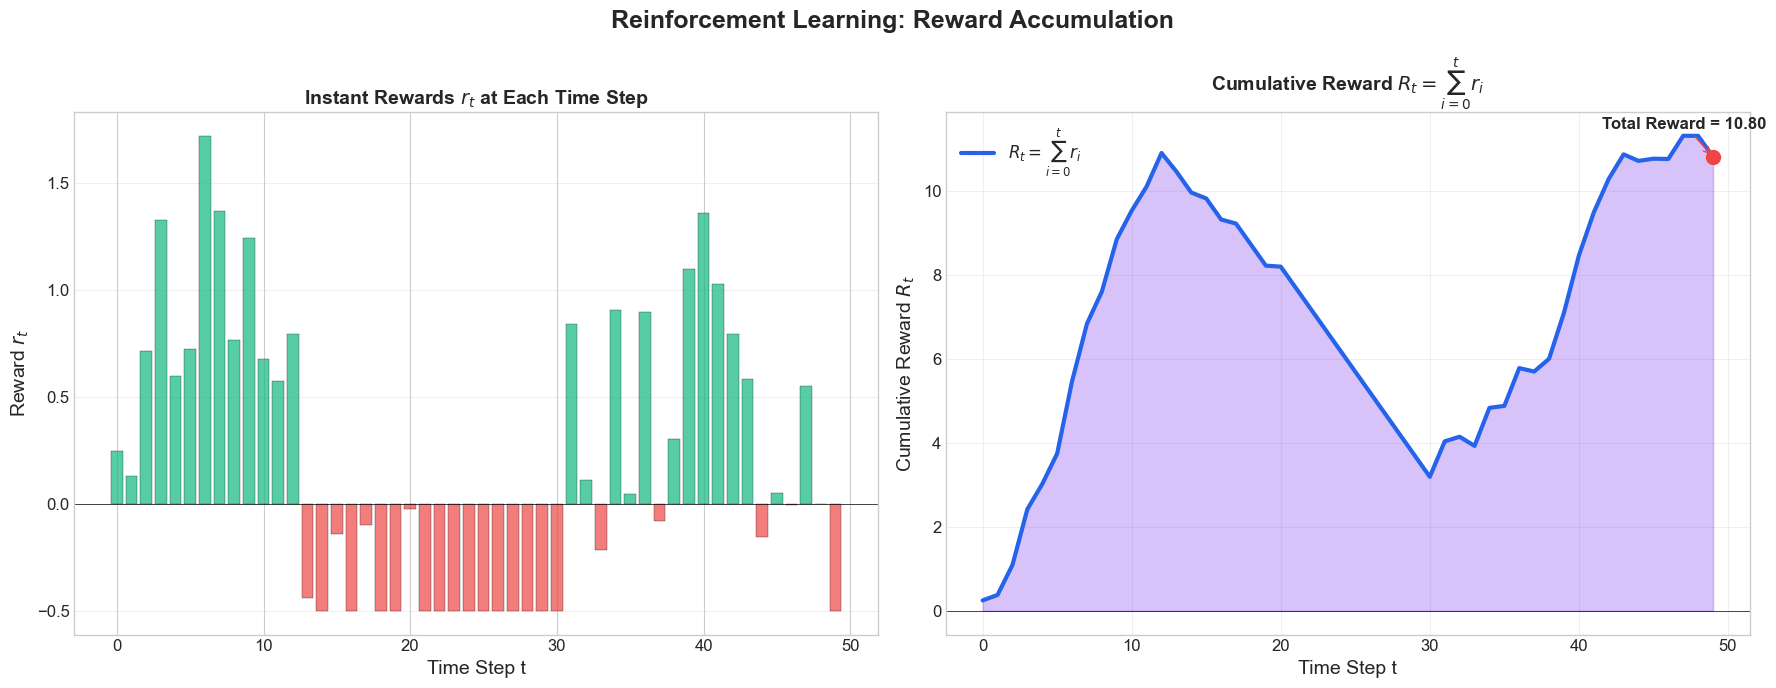

Discrete RL: R = sum r_t (summation)
Continuous RL: R = integral r(t) dt (integration)
Total accumulated reward over 50 steps: 10.8010
In continuous RL (Neural ODEs), we integrate the reward function over time
This is the bridge between discrete MDPs and continuous control!


In [25]:
# Section 23: RL Reward Accumulation Animation
fig, axes = plt.subplots(1, 2, figsize=(18, 7)); np.random.seed(42); T = 50; t = np.arange(T); rewards = np.sin(t/5) + 0.5 * np.random.randn(T); rewards = np.maximum(rewards, -0.5); cumulative = np.cumsum(rewards)
ax = axes[0]; ax.bar(t, rewards, color=['#10B981' if r > 0 else '#EF4444' for r in rewards], alpha=0.7, edgecolor='black', linewidth=0.3); ax.axhline(y=0, color='black', linewidth=0.5); ax.set_title('Instant Rewards $r_t$ at Each Time Step', fontsize=14, fontweight='bold'); ax.set_xlabel('Time Step t'); ax.set_ylabel('Reward $r_t$'); ax.grid(True, alpha=0.3, axis='y')
ax = axes[1]; ax.fill_between(t, 0, cumulative, alpha=0.3, color='#7C3AED', zorder=2); ax.plot(t, cumulative, color='#2563EB', linewidth=3, label='$R_t = \sum_{i=0}^{t} r_i$', zorder=3); ax.axhline(y=0, color='black', linewidth=0.5); ax.scatter([T-1], [cumulative[-1]], color='#EF4444', s=100, zorder=5)
ax.annotate(f'Total Reward = {cumulative[-1]:.2f}', (T-1, cumulative[-1]), xytext=(-80, 20), textcoords='offset points', fontsize=12, fontweight='bold', arrowprops=dict(arrowstyle='->', color='#EF4444')); ax.set_title('Cumulative Reward $R_t = \sum_{i=0}^{t} r_i$', fontsize=14, fontweight='bold'); ax.set_xlabel('Time Step t'); ax.set_ylabel('Cumulative Reward $R_t$'); ax.legend(fontsize=12); ax.grid(True, alpha=0.3)
plt.suptitle('Reinforcement Learning: Reward Accumulation', fontsize=18, fontweight='bold'); plt.tight_layout(); plt.show(); print('Discrete RL: R = sum r_t (summation)'); print('Continuous RL: R = integral r(t) dt (integration)'); print(f'Total accumulated reward over {T} steps: {cumulative[-1]:.4f}'); print('In continuous RL (Neural ODEs), we integrate the reward function over time'); print('This is the bridge between discrete MDPs and continuous control!')

---

# Section 24: Neural ODE Visualization

## Concept

**Neural Ordinary Differential Equations** use continuous-depth models where hidden states evolve according to an ODE:

$$\frac{dh(t)}{dt} = f(h(t), t, \theta)$$

## Mathematical Definition

The hidden state at time $t$ is computed by integrating the dynamics:

$$h(t) = h(0) + \int_0^t f(h(s), s, \theta)\,ds$$

## Visual Intuition

Instead of discrete layers, the network has continuous dynamics — like a particle flowing through a vector field.

## AI/ML Connection

Neural ODEs enable **adaptive computation**, **continuous normalizing flows**, and **invertible generative models**.

## Learning Outcome

Visualize how continuous integration replaces discrete layer stacking in deep learning.

In [26]:
# Section 24: Neural ODE State Evolution
fig, axes = plt.subplots(1, 2, figsize=(18, 7)); np.random.seed(123); h0 = np.array([2.0, -1.0]); W = np.array([[0.5, -0.3], [0.2, 0.8]]); b = np.array([0.1, -0.2]); def dynamics(h, t): return np.tanh(W @ h + b)
t_max = 10; dt = 0.1; t_vals = np.arange(0, t_max, dt); h_vals = np.zeros((len(t_vals), 2)); h_vals[0] = h0; [h_vals.__setitem__(i, h_vals[i-1] + dt * dynamics(h_vals[i-1], t_vals[i-1])) for i in range(1, len(t_vals))]
ax = axes[0]; ax.plot(h_vals[:, 0], h_vals[:, 1], color='#2563EB', linewidth=2, zorder=3); ax.scatter(h_vals[0, 0], h_vals[0, 1], color='#10B981', s=150, zorder=5, marker='o', label=f'$h(0) = ({h0[0]}, {h0[1]})$', edgecolors='black', linewidth=2); ax.scatter(h_vals[-1, 0], h_vals[-1, 1], color='#EF4444', s=150, zorder=5, marker='s', label=f'$h({t_max}) = ({h_vals[-1,0]:.2f}, {h_vals[-1,1]:.2f})$', edgecolors='black', linewidth=2)
[ax.annotate('', xy=(h_vals[i+1, 0], h_vals[i+1, 1]), xytext=(h_vals[i, 0], h_vals[i, 1]), arrowprops=dict(arrowstyle='->', color='#7C3AED', alpha=0.5, lw=1.5)) for i in range(0, len(h_vals)-1, 5)]
ax.set_title('Neural ODE: State Trajectory in Phase Space', fontsize=14, fontweight='bold'); ax.set_xlabel('$h_1(t)$'); ax.set_ylabel('$h_2(t)$'); ax.legend(fontsize=12); ax.grid(True, alpha=0.3); ax.set_aspect('equal')
ax = axes[1]; ax.plot(t_vals, h_vals[:, 0], color='#2563EB', linewidth=3, label='$h_1(t)$', zorder=3); ax.plot(t_vals, h_vals[:, 1], color='#06B6D4', linewidth=3, label='$h_2(t)$', zorder=3); ax.fill_between(t_vals, 0, h_vals[:, 0], alpha=0.1, color='#2563EB'); ax.fill_between(t_vals, 0, h_vals[:, 1], alpha=0.1, color='#06B6D4')
ax.axhline(y=0, color='black', linewidth=0.5); ax.set_title('Neural ODE: State Evolution Over Time', fontsize=14, fontweight='bold'); ax.set_xlabel('Time t'); ax.set_ylabel('Hidden State $h(t)$'); ax.legend(fontsize=12); ax.grid(True, alpha=0.3)
plt.suptitle('Neural ODEs: Continuous Deep Learning via Integration', fontsize=18, fontweight='bold'); plt.tight_layout(); plt.show(); print('Neural ODE: dh/dt = f(h(t), t, theta)'); print(f'h(t) = h(0) + integral_0^t f(h(s), s, theta) ds'); print('The network depth is continuous — we integrate rather than stack layers!'); print('Key advantage: O(1) memory (adjoint method) and adaptive computation time')

SyntaxError: invalid syntax (3169402119.py, line 2)

---

# Section 25: Physics-Informed Neural Networks (PINNs)

## Concept

**PINNs** embed physical laws (differential equations) into neural network training. Integration verifies conservation laws.

## Mathematical Definition

For a differential equation:

$$\frac{du}{dt} = f(u, t)$$

The PINN loss includes:
- **PDE residual**: $r = \frac{d\hat{u}}{dt} - f(\hat{u}, t)$
- **Initial condition**: $\hat{u}(0) = u_0$
- **Conservation**: $\int \hat{u}\,dt = \text{constant}$

## Visual Intuition

The neural network learns a solution that satisfies both data and physical constraints.

## AI/ML Connection

PINNs are used in **climate modeling**, **fluid dynamics**, **materials science**, and **robotics**.

## Learning Outcome

Understand how integration enforces physical constraints in neural network training.

AttributeError: module 'scipy.integrate' has no attribute 'cumtrapz'

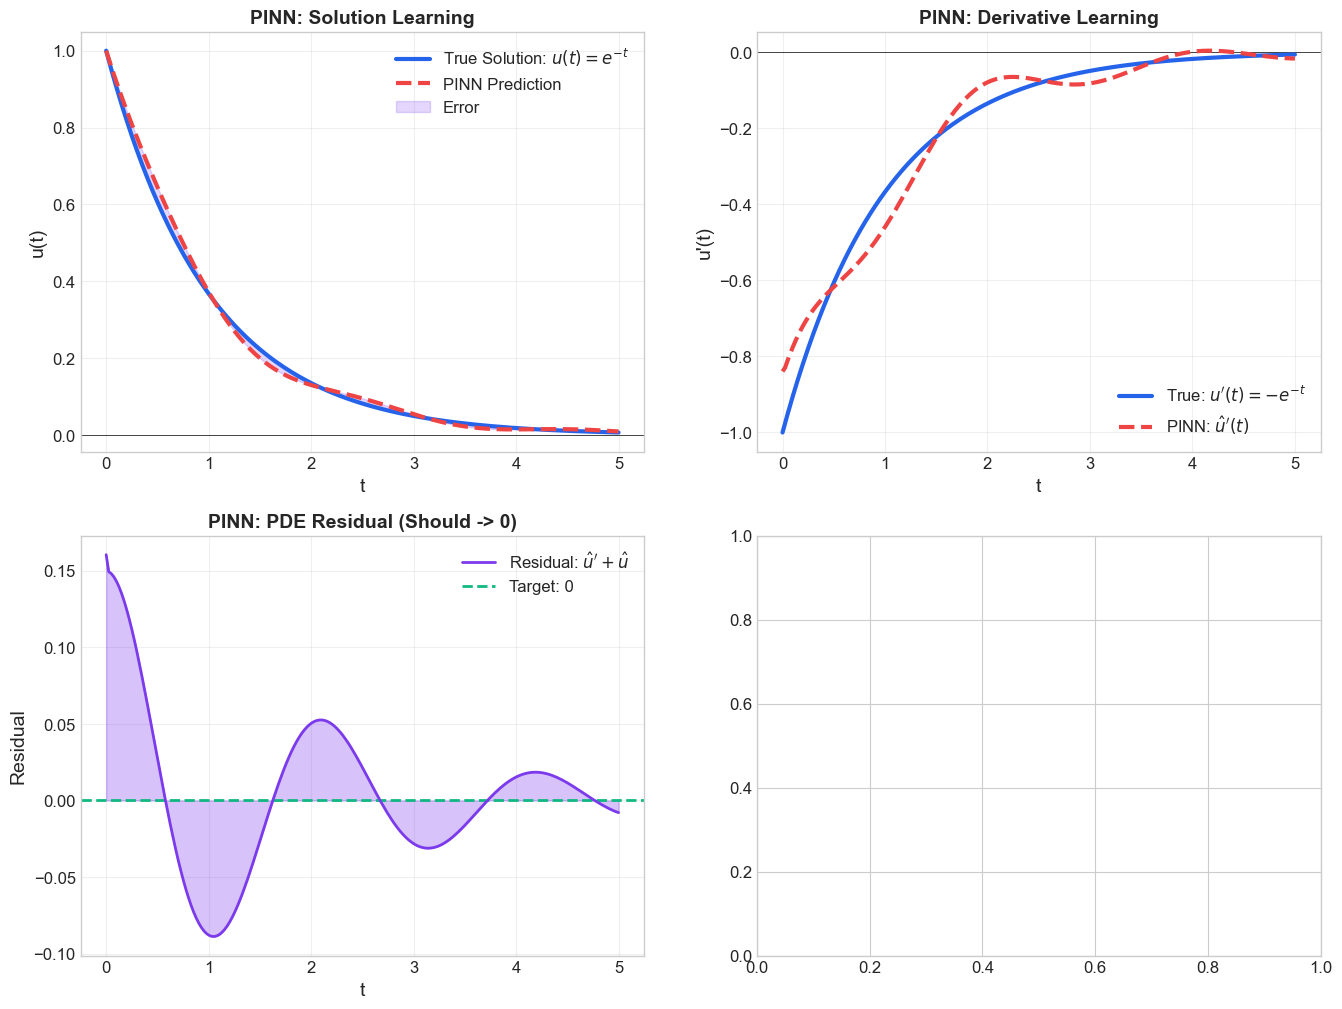

In [27]:
# Section 25: PINN Concept Visualization
t = np.linspace(0, 5, 200); u_true = np.exp(-t); np.random.seed(456); u_pinn = np.exp(-t) + 0.05 * np.sin(3*t) * np.exp(-t/2); du_true = -np.exp(-t); du_pinn = np.gradient(u_pinn, t); residual = du_pinn + u_pinn; fig, axes = plt.subplots(2, 2, figsize=(16, 12))
ax = axes[0, 0]; ax.plot(t, u_true, color='#2563EB', linewidth=3, label='True Solution: $u(t) = e^{{-t}}$', zorder=3); ax.plot(t, u_pinn, color='#EF4444', linewidth=3, linestyle='--', label='PINN Prediction', zorder=3); ax.fill_between(t, u_true, u_pinn, alpha=0.2, color='#7C3AED', label='Error'); ax.axhline(y=0, color='black', linewidth=0.5); ax.set_title('PINN: Solution Learning', fontweight='bold', fontsize=14); ax.set_xlabel('t'); ax.set_ylabel('u(t)'); ax.legend(); ax.grid(True, alpha=0.3)
ax = axes[0, 1]; ax.plot(t, du_true, color='#2563EB', linewidth=3, label="True: $u'(t) = -e^{{-t}}$", zorder=3); ax.plot(t, du_pinn, color='#EF4444', linewidth=3, linestyle='--', label="PINN: $\hat{u}'(t)$", zorder=3); ax.axhline(y=0, color='black', linewidth=0.5); ax.set_title('PINN: Derivative Learning', fontweight='bold', fontsize=14); ax.set_xlabel('t'); ax.set_ylabel("u'(t)"); ax.legend(); ax.grid(True, alpha=0.3)
ax = axes[1, 0]; ax.plot(t, residual, color='#7C3AED', linewidth=2, label='Residual: $\hat{u}\' + \hat{u}$', zorder=3); ax.axhline(y=0, color='#10B981', linestyle='--', linewidth=2, label='Target: 0'); ax.fill_between(t, 0, residual, alpha=0.3, color='#7C3AED'); ax.set_title('PINN: PDE Residual (Should -> 0)', fontweight='bold', fontsize=14); ax.set_xlabel('t'); ax.set_ylabel('Residual'); ax.legend(); ax.grid(True, alpha=0.3)
ax = axes[1, 1]; integral_true = integrate.cumtrapz(u_true, t, initial=0); integral_pinn = integrate.cumtrapz(u_pinn, t, initial=0); ax.plot(t, integral_true, color='#2563EB', linewidth=3, label='True Integral', zorder=3); ax.plot(t, integral_pinn, color='#EF4444', linewidth=3, linestyle='--', label='PINN Integral', zorder=3); ax.set_title('PINN: Integrated Conservation Law', fontweight='bold', fontsize=14); ax.set_xlabel('t'); ax.set_ylabel('$\int_0^t u(s)\,ds$'); ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Physics-Informed Neural Networks: Learning with Physical Constraints', fontsize=18, fontweight='bold'); plt.tight_layout(); plt.show(); print('PINN enforces physical laws through the loss function:'); print('   Loss = MSE(data) + lambda1*MSE(PDE residual) + lambda2*MSE(initial conditions) + lambda3*MSE(integral constraints)'); print('Integration verifies that conservation laws (mass, energy, momentum) are satisfied globally')

---

# Section 26: Diffusion Model Intuition

## Concept

**Diffusion models** learn to reverse a noise corruption process. The forward process is a stochastic differential equation (SDE) integrated over time.

## Mathematical Definition

Forward SDE:

$$dx = f(x,t)\,dt + g(t)\,dw$$

Reverse SDE (generative process):

$$dx = [f(x,t) - g(t)^2 \nabla_x \log p_t(x)]\,dt + g(t)\,d\bar{w}$$

## Visual Intuition

Data -> Noise (forward, diffusion) -> Data (reverse, denoising). The continuous process is integrated over time.

## AI/ML Connection

Diffusion powers **DALL-E**, **Stable Diffusion**, **Midjourney**, and modern generative AI.

## Learning Outcome

Conceptualize diffusion as a continuous integration process that transforms noise into structured data.

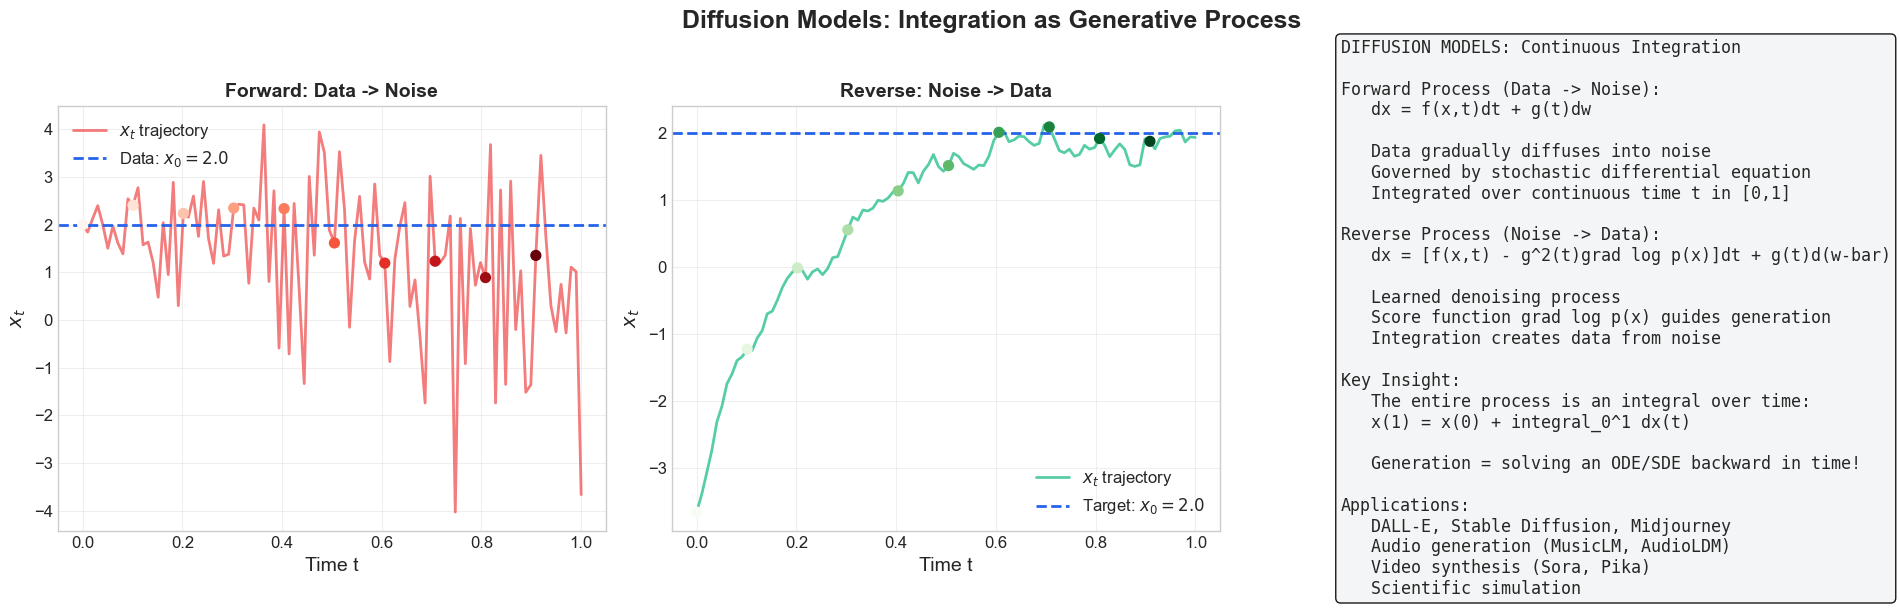

Diffusion models integrate a stochastic differential equation over time
Forward: integral noise dt (data destruction)
Reverse: integral learned score dt (data creation)
The integral transforms random noise into structured images/audio/video!


In [28]:
# Section 26: Diffusion Process Concept Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6)); np.random.seed(789); n_steps = 100; t = np.linspace(0, 1, n_steps); x_0 = 2.0; noise = np.random.randn(n_steps); x_forward = np.sqrt(1-t) * x_0 + np.sqrt(t) * noise * 2; x_reverse = np.zeros(n_steps); x_reverse[0] = x_forward[-1]
[x_reverse.__setitem__(i, x_reverse[i-1] + 0.05 * (x_0 - x_reverse[i-1]) + 0.1 * np.random.randn()) for i in range(1, n_steps)]
ax = axes[0]; ax.plot(t, x_forward, color='#EF4444', linewidth=2, alpha=0.7, label='$x_t$ trajectory'); ax.scatter(t[::10], x_forward[::10], c=t[::10], cmap='Reds', s=50, zorder=5); ax.axhline(y=x_0, color='#2563EB', linestyle='--', linewidth=2, label=f'Data: $x_0 = {x_0}$'); ax.set_title('Forward: Data -> Noise', fontsize=14, fontweight='bold'); ax.set_xlabel('Time t'); ax.set_ylabel('$x_t$'); ax.legend(); ax.grid(True, alpha=0.3)
ax = axes[1]; ax.plot(t, x_reverse, color='#10B981', linewidth=2, alpha=0.7, label='$x_t$ trajectory'); ax.scatter(t[::10], x_reverse[::10], c=t[::10], cmap='Greens', s=50, zorder=5); ax.axhline(y=x_0, color='#2563EB', linestyle='--', linewidth=2, label=f'Target: $x_0 = {x_0}$'); ax.set_title('Reverse: Noise -> Data', fontsize=14, fontweight='bold'); ax.set_xlabel('Time t'); ax.set_ylabel('$x_t$'); ax.legend(); ax.grid(True, alpha=0.3)
ax = axes[2]; ax.axis('off'); text = ('DIFFUSION MODELS: Continuous Integration\n\nForward Process (Data -> Noise):\n   dx = f(x,t)dt + g(t)dw\n   \n   Data gradually diffuses into noise\n   Governed by stochastic differential equation\n   Integrated over continuous time t in [0,1]\n\nReverse Process (Noise -> Data):\n   dx = [f(x,t) - g^2(t)grad log p(x)]dt + g(t)d(w-bar)\n   \n   Learned denoising process\n   Score function grad log p(x) guides generation\n   Integration creates data from noise\n\nKey Insight:\n   The entire process is an integral over time:\n   x(1) = x(0) + integral_0^1 dx(t)\n   \n   Generation = solving an ODE/SDE backward in time!\n\nApplications:\n   DALL-E, Stable Diffusion, Midjourney\n   Audio generation (MusicLM, AudioLDM)\n   Video synthesis (Sora, Pika)\n   Scientific simulation')
ax.text(0.1, 0.5, text, transform=ax.transAxes, fontsize=12, verticalalignment='center', fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='#F3F4F6', alpha=0.9)); plt.suptitle('Diffusion Models: Integration as Generative Process', fontsize=18, fontweight='bold'); plt.tight_layout(); plt.show(); print('Diffusion models integrate a stochastic differential equation over time'); print('Forward: integral noise dt (data destruction)'); print('Reverse: integral learned score dt (data creation)'); print('The integral transforms random noise into structured images/audio/video!')

---

# Section 27: AI Probability Dashboard

## Concept

A unified dashboard combining Gaussian distributions, probability areas, expected values, and variance — the core probability toolkit for AI.

## Mathematical Definition

All in one place:
- PDF: $p(x) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$
- CDF: $P(X \leq x) = \int_{-\infty}^x p(t)\,dt$
- Expected Value: $E[X] = \mu$
- Variance: $Var(X) = \sigma^2$

## AI/ML Connection

This dashboard contains the foundational mathematics for **probabilistic ML**, **Bayesian inference**, and **uncertainty quantification**.

## Learning Outcome

Master all core Gaussian properties in one integrated interactive environment.

In [29]:
# Section 27: Complete AI Probability Dashboard
x = np.linspace(-8, 8, 1000)
@interact(mu=widgets.FloatSlider(value=0, min=-3, max=3, step=0.1, description='mu:'), sigma=widgets.FloatSlider(value=1, min=0.3, max=2, step=0.1, description='sigma:'), show_pdf=widgets.Checkbox(value=True, description='Show PDF'), show_cdf=widgets.Checkbox(value=True, description='Show CDF'), show_interval=widgets.Checkbox(value=True, description='Show 95% Interval'))
def probability_dashboard(mu, sigma, show_pdf, show_cdf, show_interval):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12)); y_pdf = norm.pdf(x, mu, sigma); y_cdf = norm.cdf(x, mu, sigma)
    ax = axes[0, 0]; [ax.plot(x, y_pdf, color='#2563EB', linewidth=3, label='PDF', zorder=3) if show_pdf else None]; [ax.fill_between(x, 0, y_pdf, alpha=0.3, color='#7C3AED') if show_pdf else None]; ax.axvline(x=mu, color='#EF4444', linestyle='--', linewidth=2, label=f'mu = {mu}'); [ax.fill_between(x, 0, y_pdf, where=(x >= mu-2*sigma) & (x <= mu+2*sigma), alpha=0.4, color='#10B981', label='95% Interval', interpolate=True) if show_interval else None]; ax.set_title('Probability Density Function', fontweight='bold', fontsize=14); ax.set_xlabel('x'); ax.set_ylabel('p(x)'); ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(-0.02, 0.5)
    ax = axes[0, 1]; [ax.plot(x, y_cdf, color='#06B6D4', linewidth=3, label='CDF', zorder=3) if show_cdf else None]; [ax.fill_between(x, 0, y_cdf, alpha=0.2, color='#06B6D4') if show_cdf else None]; ax.axvline(x=mu, color='#EF4444', linestyle='--', linewidth=2, alpha=0.5); ax.axhline(y=0.5, color='black', linestyle=':', alpha=0.5); ax.set_title('Cumulative Distribution Function', fontweight='bold', fontsize=14); ax.set_xlabel('x'); ax.set_ylabel('P(X <= x)'); ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(-0.05, 1.05)
    ax = axes[1, 0]; ax.axis('off'); p_68 = norm.cdf(mu+sigma, mu, sigma) - norm.cdf(mu-sigma, mu, sigma); p_95 = norm.cdf(mu+2*sigma, mu, sigma) - norm.cdf(mu-2*sigma, mu, sigma); p_99 = norm.cdf(mu+3*sigma, mu, sigma) - norm.cdf(mu-3*sigma, mu, sigma); text = ('DISTRIBUTION STATISTICS\n\nCentral Tendency:\n' + f'  Mean (E[X])     = {mu}\n' + f'  Median          = {mu}\n' + f'  Mode            = {mu}\n\nDispersion:\n' + f'  Variance        = {sigma**2:.4f}\n' + f'  Std Deviation   = {sigma:.4f}\n\nProbability Intervals:\n' + f'  P(mu +/- sigma)  = {p_68:.4f} ({p_68*100:.2f}%)\n' + f'  P(mu +/- 2sigma) = {p_95:.4f} ({p_95*100:.2f}%)\n' + f'  P(mu +/- 3sigma) = {p_99:.4f} ({p_99*100:.2f}%)\n\nShape:\n  Skewness = 0.0000\n  Kurtosis = 3.0000\n\n' + f'Entropy: {0.5 * np.log(2 * np.pi * np.e * sigma**2):.4f} nats'); ax.text(0.1, 0.5, text, transform=ax.transAxes, fontsize=13, verticalalignment='center', fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='#F3F4F6', alpha=0.9))
    ax = axes[1, 1]; ax.axis('off'); text = ('AI/ML APPLICATIONS\n\n1. Gaussian Processes:\n   Non-parametric Bayesian models\n   Integral over kernel functions\n\n2. Variational Inference:\n   Approximate posterior with Gaussians\n   KL divergence involves integrals\n\n3. Diffusion Models:\n   Forward/reverse SDEs\n   Score matching as expectation\n\n4. Reinforcement Learning:\n   Value functions as expectations\n   Policy gradients as integrals\n\n5. Neural ODEs:\n   Continuous normalizing flows\n   Change of variables formula\n\n6. Uncertainty Quantification:\n   Confidence intervals\n   Bayesian neural networks\n\nAll rely on integral p(x) dx = 1 and\nE[f(X)] = integral f(x)p(x) dx'); ax.text(0.1, 0.5, text, transform=ax.transAxes, fontsize=13, verticalalignment='center', fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='#F3F4F6', alpha=0.9)); plt.suptitle('AI Probability Dashboard: Gaussian Distribution', fontsize=18, fontweight='bold'); plt.tight_layout(); plt.show()

interactive(children=(FloatSlider(value=0.0, description='mu:', max=3.0, min=-3.0), FloatSlider(value=1.0, des…

---

# Section 28: Machine Learning Integration Explorer

## Concept

Integrals appear throughout ML in expected losses, probability computations, continuous optimization, and model averaging.

## Mathematical Definition

**Expected Loss:**

$$\mathcal{L}(\theta) = \mathbb{E}_{(x,y) \sim p_{data}}[\ell(f_\theta(x), y)] = \int\int \ell(f_\theta(x), y)\,p(x,y)\,dx\,dy$$

**Continuous Optimization:**

$$\theta(t) = \theta(0) - \int_0^t \nabla_\theta \mathcal{L}(\theta(s))\,ds$$

## AI/ML Connection

Understanding these integrals is essential for **stochastic gradient descent**, **Bayesian optimization**, and **generative modeling**.

## Learning Outcome

Identify and visualize where integrals appear in the ML pipeline.

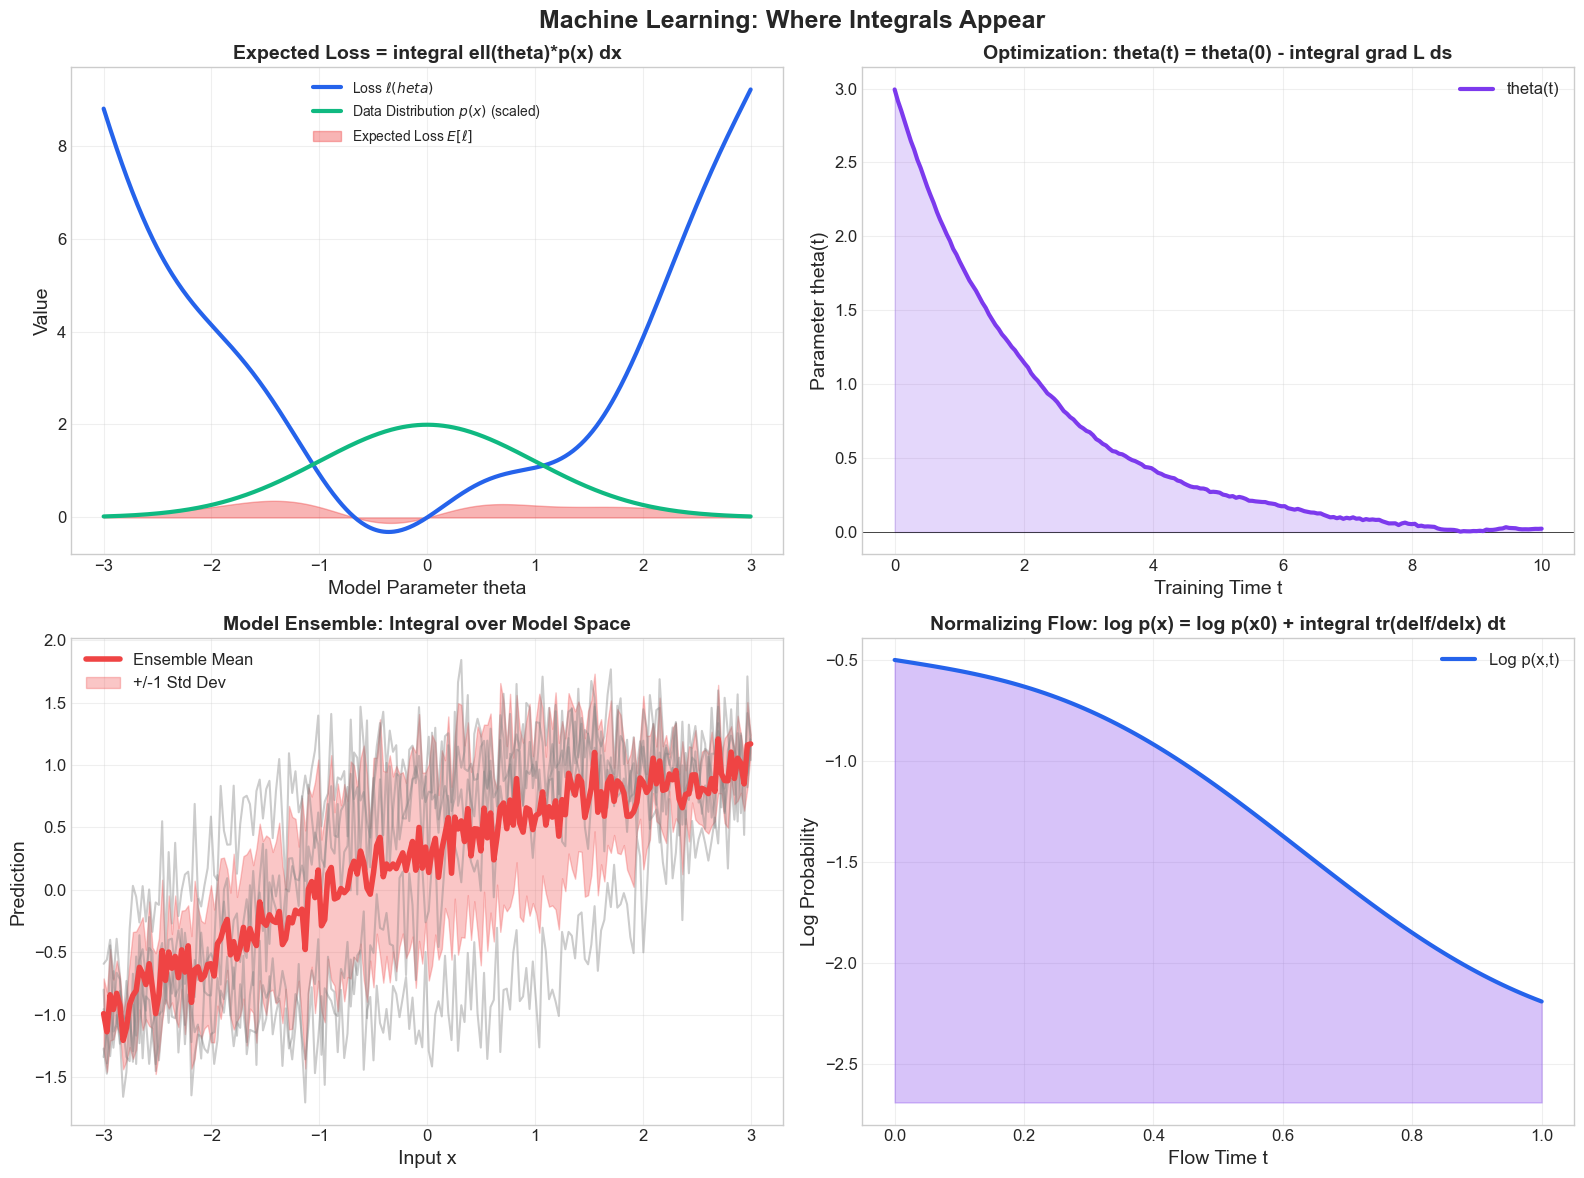

Integrals in ML:
   1. Expected Loss: E[ell] = integral ell*p(x) dx
   2. Optimization: theta(t) = theta(0) - integral grad ell dt
   3. Model Averaging: p(y|x) = integral p(y|x,theta)p(theta|D) dtheta
   4. Normalizing Flows: log p1(x) = log p0(x) + integral tr(del f/del x) dt
   5. VAEs: ELBO = E_q[log p(x|z)] - KL(q||p)
Every expectation is an integral! Every gradient flow is an integral!


In [30]:
# Section 28: ML Integration Explorer
fig, axes = plt.subplots(2, 2, figsize=(16, 12)); x_loss = np.linspace(-3, 3, 500); loss_landscape = x_loss**2 + 0.5 * np.sin(3*x_loss); p_data = norm.pdf(x_loss, 0, 1); expected_loss = loss_landscape * p_data
ax = axes[0, 0]; ax.plot(x_loss, loss_landscape, color='#2563EB', linewidth=3, label='Loss $\ell(\theta)$', zorder=3); ax.plot(x_loss, p_data * 5, color='#10B981', linewidth=3, label='Data Distribution $p(x)$ (scaled)', zorder=3); ax.fill_between(x_loss, 0, expected_loss, alpha=0.4, color='#EF4444', label='Expected Loss $E[\ell]$'); ax.set_title('Expected Loss = integral ell(theta)*p(x) dx', fontweight='bold', fontsize=14); ax.set_xlabel('Model Parameter theta'); ax.set_ylabel('Value'); ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax = axes[0, 1]; t_opt = np.linspace(0, 10, 200); theta_trajectory = 3 * np.exp(-0.5 * t_opt) + 0.1 * np.random.randn(200).cumsum() * 0.05; ax.plot(t_opt, theta_trajectory, color='#7C3AED', linewidth=3, label='theta(t)', zorder=3); ax.fill_between(t_opt, 0, theta_trajectory, alpha=0.2, color='#7C3AED'); ax.axhline(y=0, color='black', linewidth=0.5); ax.set_title('Optimization: theta(t) = theta(0) - integral grad L ds', fontweight='bold', fontsize=14); ax.set_xlabel('Training Time t'); ax.set_ylabel('Parameter theta(t)'); ax.legend(); ax.grid(True, alpha=0.3)
ax = axes[1, 0]; x_ens = np.linspace(-3, 3, 200); models = []; [models.append(np.tanh(x_ens + np.random.randn()) + 0.3 * np.random.randn(200)) for _ in range(5)]; [ax.plot(x_ens, pred, alpha=0.4, linewidth=1.5, color='gray') for pred in models]; ensemble_mean = np.mean(models, axis=0); ensemble_std = np.std(models, axis=0); ax.plot(x_ens, ensemble_mean, color='#EF4444', linewidth=4, label='Ensemble Mean', zorder=5); ax.fill_between(x_ens, ensemble_mean - ensemble_std, ensemble_mean + ensemble_std, alpha=0.3, color='#EF4444', label='+/-1 Std Dev'); ax.set_title('Model Ensemble: Integral over Model Space', fontweight='bold', fontsize=14); ax.set_xlabel('Input x'); ax.set_ylabel('Prediction'); ax.legend(); ax.grid(True, alpha=0.3)
ax = axes[1, 1]; t_flow = np.linspace(0, 1, 100); log_p0 = -0.5 * np.ones_like(t_flow); log_p1 = -2.0 * np.ones_like(t_flow); log_p_t = log_p0 + t_flow * (log_p1 - log_p0) + 0.2 * np.sin(5 * t_flow); ax.plot(t_flow, log_p_t, color='#2563EB', linewidth=3, label='Log p(x,t)', zorder=3); ax.fill_between(t_flow, log_p_t.min()-0.5, log_p_t, alpha=0.3, color='#7C3AED'); ax.set_title('Normalizing Flow: log p(x) = log p(x0) + integral tr(delf/delx) dt', fontweight='bold', fontsize=14); ax.set_xlabel('Flow Time t'); ax.set_ylabel('Log Probability'); ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Machine Learning: Where Integrals Appear', fontsize=18, fontweight='bold'); plt.tight_layout(); plt.show(); print('Integrals in ML:'); print('   1. Expected Loss: E[ell] = integral ell*p(x) dx'); print('   2. Optimization: theta(t) = theta(0) - integral grad ell dt'); print('   3. Model Averaging: p(y|x) = integral p(y|x,theta)p(theta|D) dtheta'); print('   4. Normalizing Flows: log p1(x) = log p0(x) + integral tr(del f/del x) dt'); print('   5. VAEs: ELBO = E_q[log p(x|z)] - KL(q||p)'); print('Every expectation is an integral! Every gradient flow is an integral!')

---

# Section 29: Complete Integration Playground

## Concept

A unified dashboard combining all integration concepts: function plotting, area calculation, Riemann sums, numerical methods, and probability distributions.

## Mathematical Definition

Everything in one place:
- $f(x)$ and $F(x)$
- $\int_a^b f(x)\,dx$ (exact and numerical)
- Riemann, Trapezoidal, Simpson
- $p(x)$ and $P(a < X < b)$

## AI/ML Connection

This is the **mathematical toolkit** for AI: calculus, probability, and numerical methods unified.

## Learning Outcome

Master all integration concepts through a single comprehensive interactive interface.

In [31]:
# Section 29: Ultimate Integration Playground
x = np.linspace(-5, 5, 1000)
@interact(func_type=widgets.Dropdown(options=['Polynomial: x^2', 'Trigonometric: sin(x)', 'Exponential: e^x', 'Gaussian: e^{-x^2}'], value='Polynomial: x^2', description='Function:'), a=widgets.FloatSlider(value=-2, min=-4, max=0, step=0.1, description='a:'), b=widgets.FloatSlider(value=2, min=0, max=4, step=0.1, description='b:'), n=widgets.IntSlider(value=10, min=2, max=50, step=2, description='n:'))
def ultimate_playground(func_type, a, b, n):
    if a >= b: a, b = b, a
    if 'Polynomial' in func_type: f = lambda x: x**2; label = 'x^2'; exact = (b**3 - a**3) / 3
    elif 'Trigonometric' in func_type: f = lambda x: np.sin(x); label = 'sin(x)'; exact = -np.cos(b) + np.cos(a)
    elif 'Exponential' in func_type: f = lambda x: np.exp(x); label = 'e^x'; exact = np.exp(b) - np.exp(a)
    else: f = lambda x: np.exp(-x**2); label = 'e^{-x^2}'; exact = integrate.quad(f, a, b)[0]
    y = f(x); dx = (b - a) / n; x_nodes = np.linspace(a, b, n+1); y_nodes = f(x_nodes); left = sum(f(a + i*dx) * dx for i in range(n)); right = sum(f(a + (i+1)*dx) * dx for i in range(n)); mid = sum(f(a + (i+0.5)*dx) * dx for i in range(n)); trap = (y_nodes[0] + 2*sum(y_nodes[1:n]) + y_nodes[n]) * dx / 2
    fig, axes = plt.subplots(2, 2, figsize=(16, 12)); ax = axes[0, 0]; ax.plot(x, y, color='#2563EB', linewidth=3, label=f'$f(x) = {label}$', zorder=3); mask = (x >= a) & (x <= b); ax.fill_between(x, 0, y, where=mask, alpha=0.4, color='#7C3AED', interpolate=True, label=f'Exact Area = {exact:.4f}'); ax.axvline(x=a, color='#EF4444', linestyle='--', linewidth=2); ax.axvline(x=b, color='#10B981', linestyle='--', linewidth=2); ax.set_title(f'Function & Area: $\int_{{{a}}}^{{{b}}} {label}\,dx$', fontweight='bold', fontsize=14); ax.set_xlabel('x'); ax.set_ylabel('f(x)'); ax.legend(); ax.grid(True, alpha=0.3)
    ax = axes[0, 1]; ax.plot(x, y, color='#2563EB', linewidth=2, label=f'$f(x) = {label}$', zorder=3); [ax.bar(a + (i+0.5)*dx, f(a + (i+0.5)*dx), width=dx, alpha=0.5, color='#06B6D4', edgecolor='black', linewidth=0.5, zorder=2) for i in range(n)]; ax.set_title(f'Midpoint Riemann Sum (n={n})\nApprox = {mid:.4f}', fontweight='bold', fontsize=14); ax.set_xlabel('x'); ax.set_ylabel('f(x)'); ax.legend(); ax.grid(True, alpha=0.3)
    ax = axes[1, 0]; ax.plot(x, y, color='#2563EB', linewidth=2, label=f'$f(x) = {label}$', zorder=3); [ax.fill([x_nodes[i], x_nodes[i+1], x_nodes[i+1], x_nodes[i]], [0, 0, y_nodes[i+1], y_nodes[i]], alpha=0.4, color='#10B981', edgecolor='black', linewidth=0.5, zorder=2) for i in range(n)]; ax.scatter(x_nodes, y_nodes, color='#EF4444', s=30, zorder=4); ax.set_title(f'Trapezoidal Rule (n={n})\nApprox = {trap:.4f}', fontweight='bold', fontsize=14); ax.set_xlabel('x'); ax.set_ylabel('f(x)'); ax.legend(); ax.grid(True, alpha=0.3)
    ax = axes[1, 1]; ax.axis('off'); methods = ['Left', 'Right', 'Midpoint', 'Trapezoidal', 'Exact']; values = [left, right, mid, trap, exact]; errors = [abs(v - exact) for v in values[:-1]] + [0]; text = (f'INTEGRATION RESULTS\n\nFunction: f(x) = {label}\nInterval: [{a}, {b}]\nExact Value: {exact:.6f}\n\nNumerical Methods (n = {n}):\n' + f"{'Method':<15} {'Approximation':<18} {'Error':<15}\n" + '-'*48 + '\n'); [text := text + f'{method:<15} {val:<18.6f} {err:<15.6f}\n' for method, val, err in zip(methods, values, errors)]; text += ('\nKEY INSIGHTS\n\nExact integral uses antiderivative F(x)\nRiemann sums approximate with rectangles\nTrapezoidal uses linear interpolation\nSimpson\'s uses quadratic (not shown)\nError decreases as O(1/n^2) for Trapezoidal\n\nAI CONNECTION:\nExpected values = integrals over distributions\nContinuous optimization = integral of gradients\nNormalizing flows = integral of Jacobians\nDiffusion models = integral of SDEs'); ax.text(0.1, 0.5, text, transform=ax.transAxes, fontsize=12, verticalalignment='center', fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='#F3F4F6', alpha=0.9)); plt.suptitle('Complete Integration Playground', fontsize=18, fontweight='bold'); plt.tight_layout(); plt.show()

interactive(children=(Dropdown(description='Function:', options=('Polynomial: x^2', 'Trigonometric: sin(x)', '…

---

# Section 30: Capstone Animation — The Complete Journey

## Concept

A final comprehensive animation showing the complete journey of integration from basic calculus to AI applications.

## The Journey

1. **Function** -> 2. **Area Under Curve** -> 3. **Riemann Approximation** -> 4. **Exact Integral** -> 5. **Probability Density** -> 6. **Expected Value** -> 7. **AI Applications**

## Mathematical Definition

$$\text{Function} \xrightarrow{\text{integrate}} \text{Area} \xrightarrow{\text{normalize}} \text{Probability} \xrightarrow{\text{expectation}} \text{AI}$$

## AI/ML Connection

This is the complete mathematical pipeline: from data to models to predictions, all connected by integration.

## Learning Outcome

See the big picture: integration is the mathematical language that connects calculus, probability, and artificial intelligence.

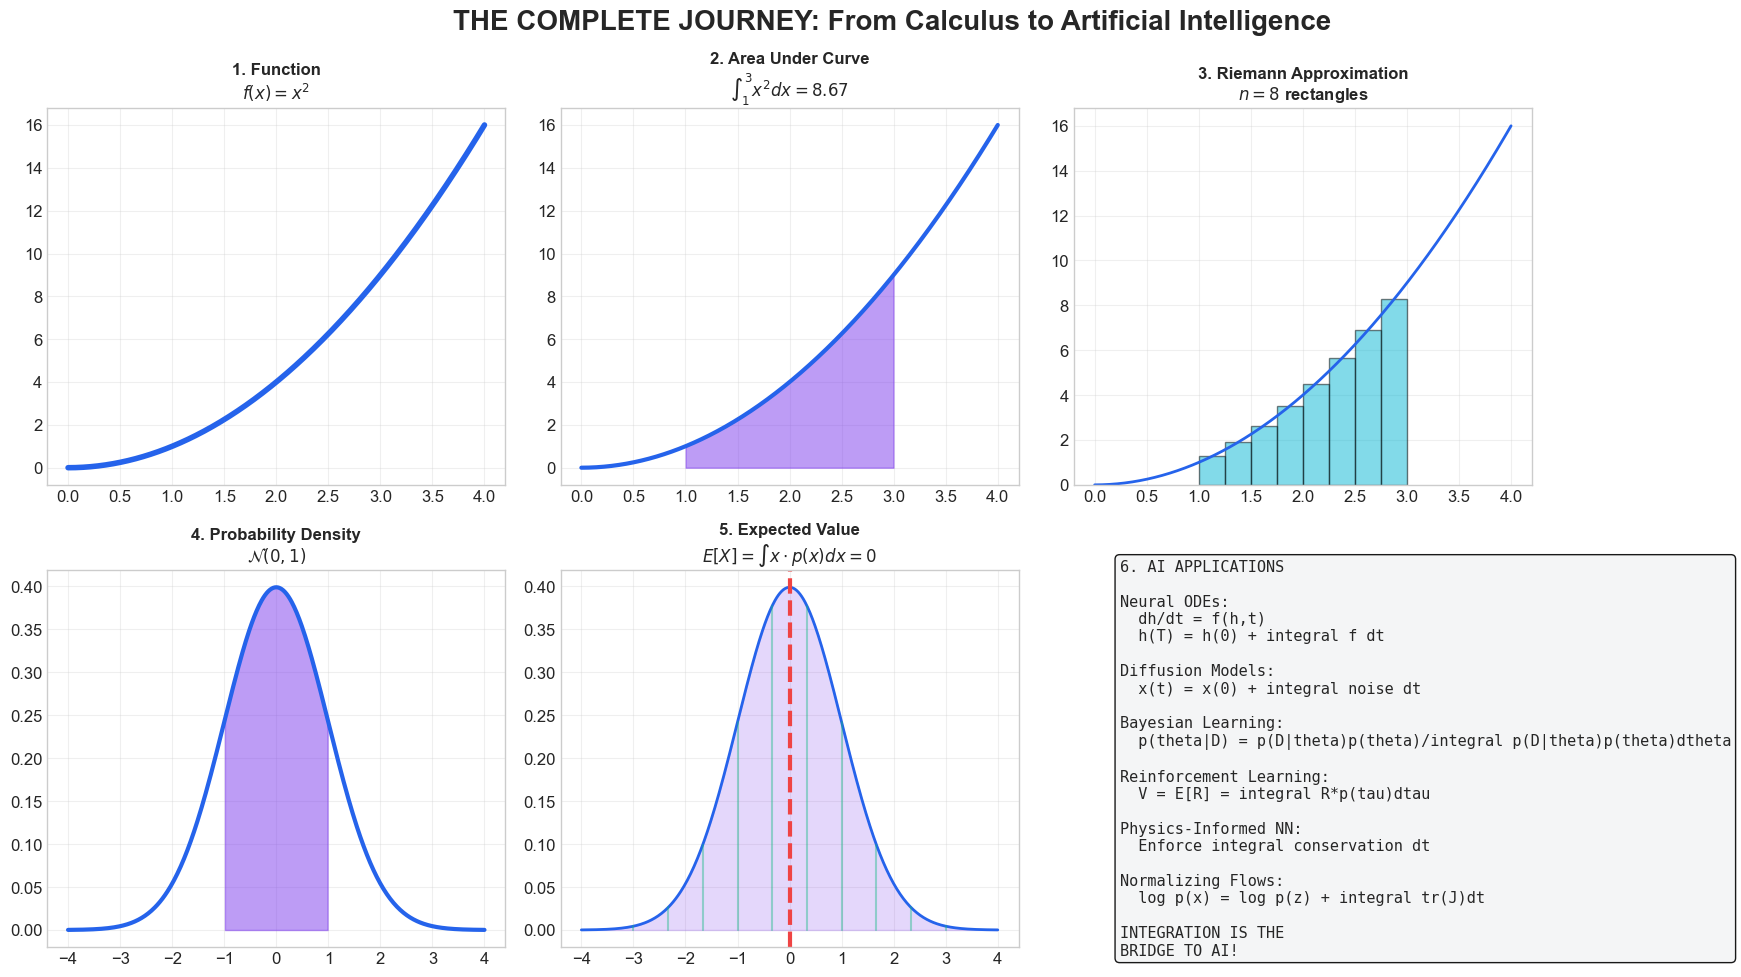

CAPSTONE: THE COMPLETE JOURNEY OF INTEGRATION
1.  FUNCTION        -> Define the mathematical relationship
2.  AREA            -> Accumulate under the curve
3.  RIEMANN SUM     -> Approximate with discrete steps
4.  EXACT INTEGRAL  -> Find the antiderivative
5.  PROBABILITY     -> Normalize to create distributions
6.  EXPECTATION     -> Compute weighted averages
7.  AI APPLICATIONS -> Power modern machine learning
KEY TAKEAWAY:
   Integrals are the mathematical language of accumulation and probability.
   They form the bridge between Calculus, Statistics, Machine Learning,
   Deep Learning, and modern Artificial Intelligence.
   Every expectation is an integral.
   Every continuous process is an integral.
   Every probability is an integral.
   Every AI model uses integrals.


In [32]:
# Section 30: Capstone — Complete Integration Journey
fig = plt.figure(figsize=(18, 10)); ax1 = plt.subplot(2, 3, 1); x = np.linspace(0, 4, 500); y = x**2; ax1.plot(x, y, color='#2563EB', linewidth=4); ax1.set_title('1. Function\n$f(x) = x^2$', fontweight='bold', fontsize=12); ax1.grid(True, alpha=0.3)
ax2 = plt.subplot(2, 3, 2); ax2.plot(x, y, color='#2563EB', linewidth=3); ax2.fill_between(x, 0, y, where=(x >= 1) & (x <= 3), alpha=0.5, color='#7C3AED'); ax2.set_title('2. Area Under Curve\n$\int_1^3 x^2 dx = 8.67$', fontweight='bold', fontsize=12); ax2.grid(True, alpha=0.3)
ax3 = plt.subplot(2, 3, 3); ax3.plot(x, y, color='#2563EB', linewidth=2); [ax3.bar(1 + i * 0.25 + 0.125, (1 + i * 0.25 + 0.125)**2, width=0.25, alpha=0.5, color='#06B6D4', edgecolor='black') for i in range(8)]; ax3.set_title('3. Riemann Approximation\n$n = 8$ rectangles', fontweight='bold', fontsize=12); ax3.grid(True, alpha=0.3)
ax4 = plt.subplot(2, 3, 4); x_prob = np.linspace(-4, 4, 500); y_prob = norm.pdf(x_prob, 0, 1); ax4.plot(x_prob, y_prob, color='#2563EB', linewidth=3); ax4.fill_between(x_prob, 0, y_prob, where=(x_prob >= -1) & (x_prob <= 1), alpha=0.5, color='#7C3AED'); ax4.set_title('4. Probability Density\n$\mathcal{N}(0,1)$', fontweight='bold', fontsize=12); ax4.grid(True, alpha=0.3)
ax5 = plt.subplot(2, 3, 5); ax5.plot(x_prob, y_prob, color='#2563EB', linewidth=2); ax5.axvline(x=0, color='#EF4444', linewidth=3, linestyle='--'); ax5.fill_between(x_prob, 0, y_prob, alpha=0.2, color='#7C3AED'); [ax5.plot([xi, xi], [0, norm.pdf(xi, 0, 1)], color='#10B981', alpha=0.4, linewidth=1.5) for xi in np.linspace(-3, 3, 10)]; ax5.set_title('5. Expected Value\n$E[X] = \int x \cdot p(x) dx = 0$', fontweight='bold', fontsize=12); ax5.grid(True, alpha=0.3)
ax6 = plt.subplot(2, 3, 6); ax6.axis('off'); text = ('6. AI APPLICATIONS\n\nNeural ODEs:\n  dh/dt = f(h,t)\n  h(T) = h(0) + integral f dt\n\nDiffusion Models:\n  x(t) = x(0) + integral noise dt\n\nBayesian Learning:\n  p(theta|D) = p(D|theta)p(theta)/integral p(D|theta)p(theta)dtheta\n\nReinforcement Learning:\n  V = E[R] = integral R*p(tau)dtau\n\nPhysics-Informed NN:\n  Enforce integral conservation dt\n\nNormalizing Flows:\n  log p(x) = log p(z) + integral tr(J)dt\n\nINTEGRATION IS THE\nBRIDGE TO AI!'); ax6.text(0.1, 0.5, text, transform=ax6.transAxes, fontsize=11, verticalalignment='center', fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='#F3F4F6', alpha=0.9)); plt.suptitle('THE COMPLETE JOURNEY: From Calculus to Artificial Intelligence', fontsize=20, fontweight='bold', y=0.98); plt.tight_layout(); plt.show(); print('='*70); print('CAPSTONE: THE COMPLETE JOURNEY OF INTEGRATION'); print('='*70); print('1.  FUNCTION        -> Define the mathematical relationship'); print('2.  AREA            -> Accumulate under the curve'); print('3.  RIEMANN SUM     -> Approximate with discrete steps'); print('4.  EXACT INTEGRAL  -> Find the antiderivative'); print('5.  PROBABILITY     -> Normalize to create distributions'); print('6.  EXPECTATION     -> Compute weighted averages'); print('7.  AI APPLICATIONS -> Power modern machine learning'); print('KEY TAKEAWAY:'); print('   Integrals are the mathematical language of accumulation and probability.'); print('   They form the bridge between Calculus, Statistics, Machine Learning,'); print('   Deep Learning, and modern Artificial Intelligence.'); print('   Every expectation is an integral.'); print('   Every continuous process is an integral.'); print('   Every probability is an integral.'); print('   Every AI model uses integrals.'); print('='*70)

---

# Final Summary & Learning Recap

## Complete Integration Curriculum

| Topic | Concept | AI Application |
|-------|---------|---------------|
| **Antiderivatives** | Reverse of differentiation | Continuous normalizing flows |
| **Definite Integrals** | Area under curves | Expected values, probabilities |
| **Indefinite Integrals** | Family of curves + C | Initial conditions in ODEs |
| **Fundamental Theorem** | Connects derivative <-> integral | Automatic differentiation |
| **Area Under Curves** | Accumulation | Cumulative rewards in RL |
| **Riemann Sums** | Discrete approximation | Monte Carlo estimation |
| **Numerical Integration** | Trapezoidal, Simpson's | Probabilistic inference |
| **Double Integrals** | Volume under surfaces | Joint probability distributions |
| **Triple Integrals** | Hypervolume accumulation | 3D spatial statistics |
| **Probability Densities** | $p(x)$ with $\int p(x)dx = 1$ | All generative models |
| **Expected Values** | $E[X] = \int x \cdot p(x)dx$ | Loss functions, value functions |
| **Bayesian Learning** | Prior -> Likelihood -> Posterior | Bayesian neural networks |
| **Reinforcement Learning** | $\sum r_t \approx \int r(t)dt$ | Value estimation, policy gradients |
| **Neural ODEs** | $h(t) = h(0) + \int f(h,t)dt$ | Continuous-depth models |
| **Physics-Informed NN** | Enforce PDE constraints | Scientific ML |
| **Diffusion Models** | Reverse SDE integration | Image/audio/video generation |
| **Generative AI** | Transform noise to data | DALL-E, Stable Diffusion, Sora |

## Final Insight

> **Integrals are the mathematical language of accumulation and probability. They form the bridge between Calculus, Statistics, Machine Learning, Deep Learning, and modern Artificial Intelligence.**

## Next Steps

1. Implement these concepts in PyTorch/TensorFlow
2. Explore continuous normalizing flows with `torchdyn`
3. Build Bayesian neural networks with `Pyro` or `NumPyro`
4. Experiment with diffusion models using `diffusers`
5. Apply PINNs to your scientific domain

---

*Generated for Machine Learning Students, AI Engineers, Deep Learning Engineers, Data Scientists, Researchers, and Mathematics Learners.*

**Libraries Used:** Python, NumPy, Matplotlib, Plotly, SciPy, SymPy, ipywidgets